[INFO] Raw file loaded. Total characters: 551,398
[INFO] Paragraphs after length filter: 2897
[INFO] Clean documents retained: 2393

          DATASET STATISTICS
  Total documents (paragraphs) :      2,393
  Total tokens                 :     69,086
  Vocabulary size              :      6,810
  Avg. tokens per document     :       28.9
  Content tokens (no stopword) :     42,866
  Unique content words         :      6,632

  Top 25 most frequent words (all):
     1. the                     4251
     2. of                      3009
     3. and                     2429
     4. to                      1648
     5. in                      1527
     6. for                     1338
     7. be                       861
     8. student                  560
     9. by                       552
    10. will                     536
    11. as                       529
    12. is                       523
    13. with                     520
    14. or                       473
    15. on         

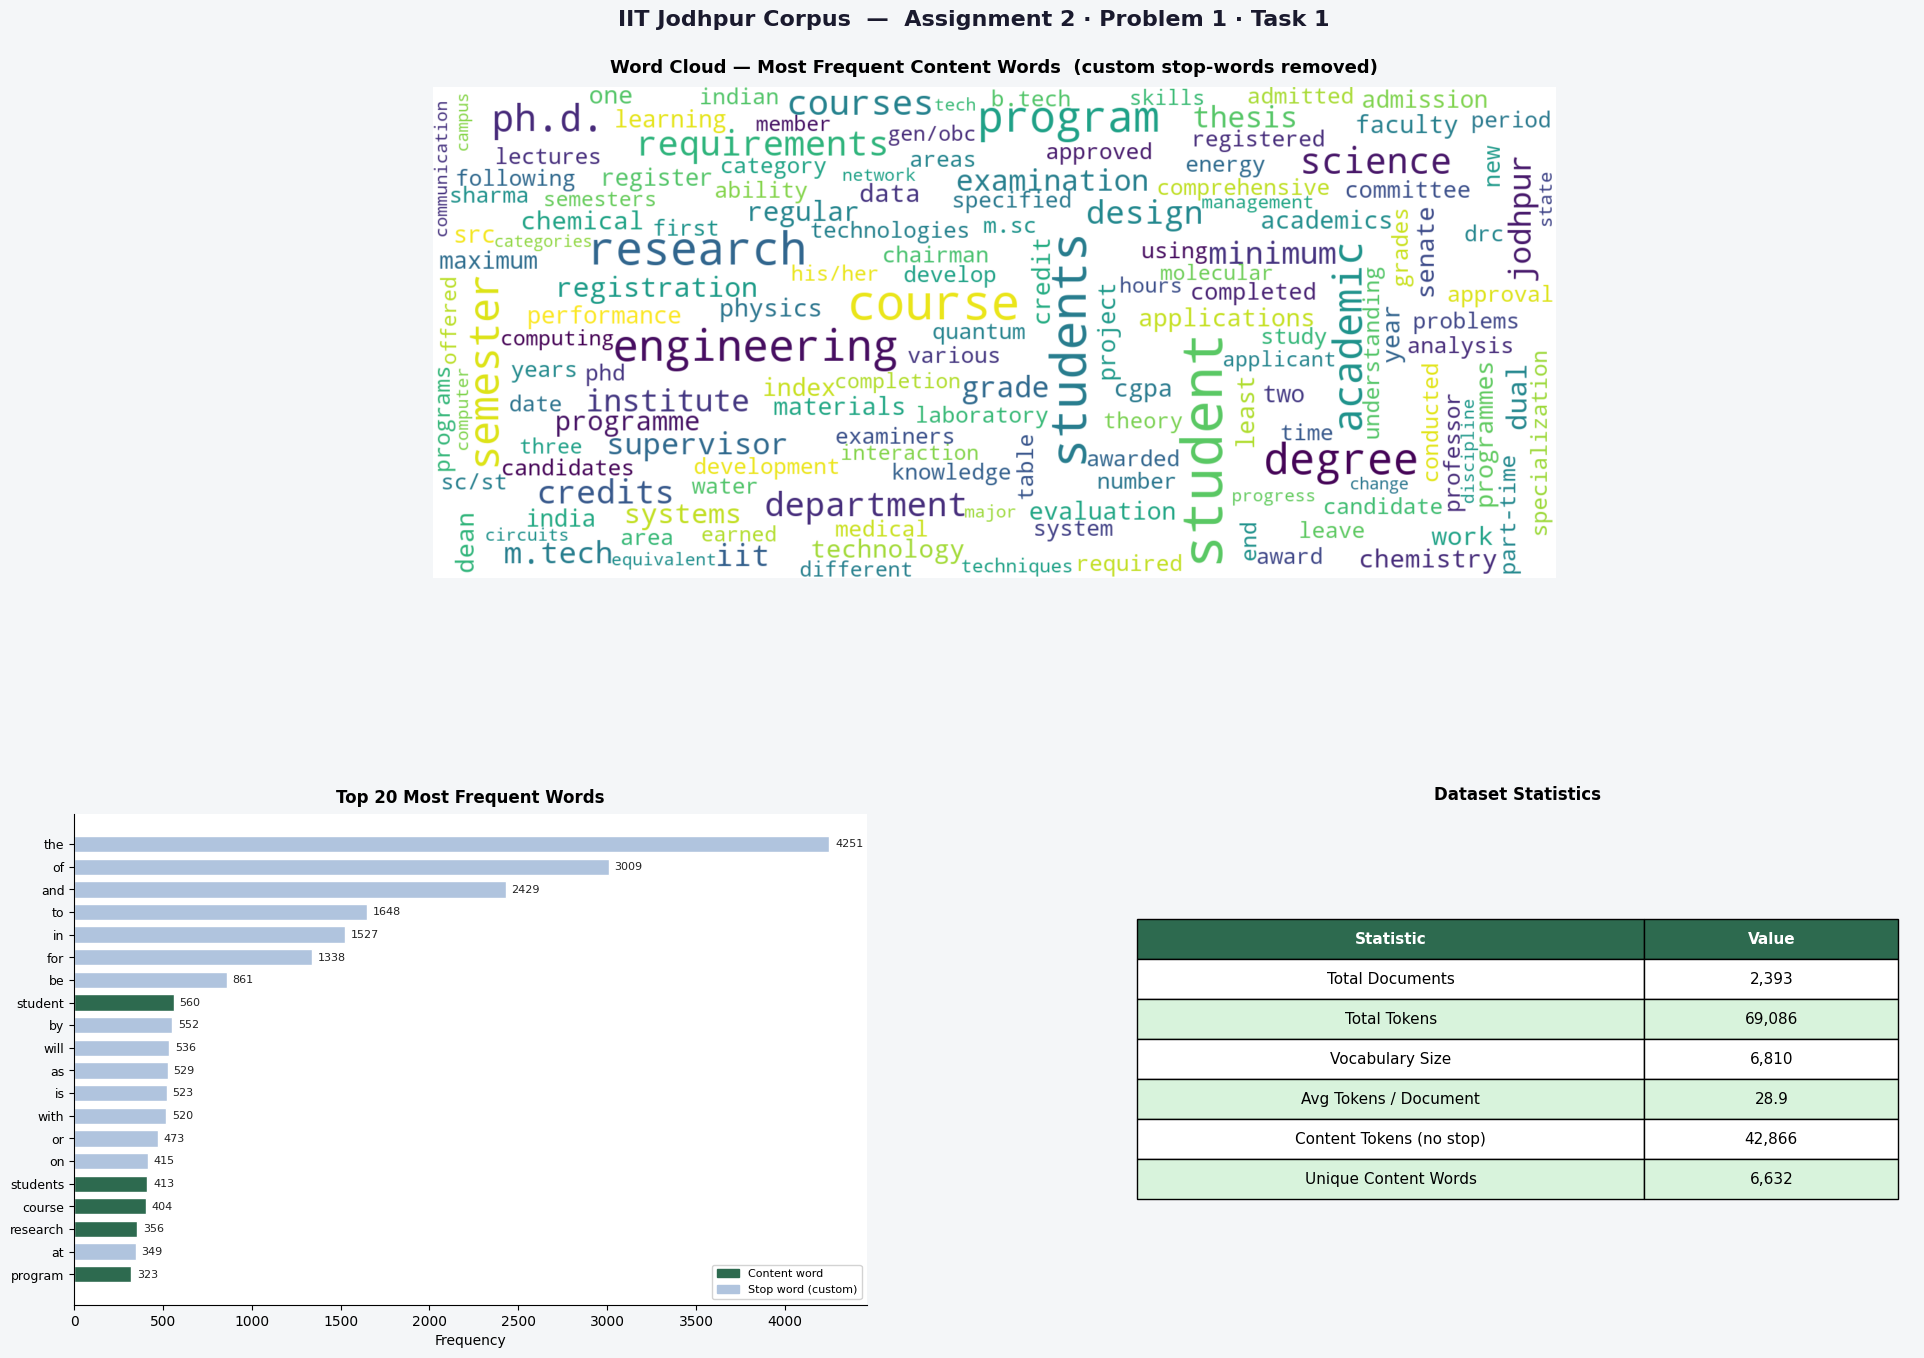

[INFO] Visualisation saved → iitj_task1_analysis.png
Cleaned corpus saved to iitj_cleaned_corpus.txt


In [ ]:
import re
import string
from collections import Counter

import nltk
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

import re, string, math, random, time, itertools
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import nltk
from nltk.tokenize import word_tokenize
import json

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# CUSTOM STOPWORD LIST
# I built this manually instead of using NLTK's list so that we have full control over what gets filtered.
# Covers the usual - articles, prepositions, pronouns, auxiliaries plus some
# web-scraping things that kept showing up in the IIT Jodhpur pages.

STOP_WORDS = {
    'a', 'an', 'the', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by', 'from', 'into',
    'through', 'during', 'before', 'after', 'above', 'below', 'between',
    'out', 'off', 'over', 'under', 'again', 'about', 'against', 'up',
    'down', 'per', 'upon', 'within', 'without', 'along', 'across', 'cr',
    'and', 'or', 'but', 'nor', 'so', 'yet', 'both', 'either', 'neither',
    'whether', 'although', 'because', 'since', 'unless', 'while', 'if',
    'than', 'that', 'though', 'as',
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves',
    'you', 'your', 'yours', 'yourself', 'yourselves',
    'he', 'him', 'his', 'himself', 'she', 'her', 'hers', 'herself',
    'it', 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves',
    'what', 'which', 'who', 'whom', 'this', 'these', 'those',
    'is', 'are', 'was', 'were', 'be', 'been', 'being',
    'have', 'has', 'had', 'having',
    'do', 'does', 'did', 'doing',
    'will', 'would', 'shall', 'should', 'may', 'might',
    'must', 'can', 'could', 'need', 'dare', 'ought',
    'not', 'no', 'nor', 'only', 'also', 'just', 'very', 'too', 'more',
    'most', 'such', 'then', 'than', 'so', 'here', 'there', 'when',
    'where', 'why', 'how', 'all', 'any', 'each', 'every', 'few',
    'same', 'other', 'own', 'once', 'now', 'any', 'well', 'even',
    'still', 'already', 'always', 'never', 'often', 'however',
    'therefore', 'thus', 'hence', 'further', 'rather', 'quite',
    'get', 'got', 'make', 'made', 'take', 'taken', 'come',
    'came', 'give', 'given', 'use', 'used', 'know', 'known', 'go',
    'going', 'gone', 'see', 'seen', 'say', 'said', 'want', 'like',
    'need', 'include', 'includes', 'including', 'provide', 'provides',
    'provided', 'based', 'related',
    'page', 'pages', 'click', 'link', 'links', 'site', 'web', 'www',
    'http', 'https', 'html', 'pdf', 'menu', 'nav', 'home', 'back',
    'next', 'prev', 'previous', 'top', 'skip', 'content', 'read',
    'more', 'email', 'contact', 'please', 'note',
}

# Loading raw corpus

RAW_FILE = "corpus.txt"

with open(RAW_FILE, "r", encoding="utf-8") as f:
    raw_text = f.read()

print(f"[INFO] Raw file loaded. Total characters: {len(raw_text):,}")

# Splitting into documents (paragraphs)
# Treating each blank-line-separated block as one document makes sense for web-scraped content where paragraphs are
# naturally self-contained chunks of information.

raw_documents = [block.strip() for block in re.split(r'\n\s*\n', raw_text)]

# drop anything under 30 chars those are usually stray nav labels, lone numbers, or single words left over from the scrape
raw_documents = [doc for doc in raw_documents if len(doc) >= 30]
print(f"[INFO] Paragraphs after length filter: {len(raw_documents)}")

# Preprocessing pipeline
# Two functions: one strips junk before tokenising, the other does the actual tokenisation + filtering.

# regex patterns for nav/footer phrases that the scraper picked up
# these add noise without any linguistic value
BOILERPLATE_PATTERNS = [
    r'\bhome\b', r'\bmenu\b', r'\bsearch\b', r'\blogin\b', r'\blogout\b',
    r'skip to content', r'read more', r'click here', r'back to top',
    r'copyright', r'all rights reserved', r'privacy policy',
]

def strip_noise(text):
    """
    Cleans up a raw paragraph before we tokenise it.
    Removes URLs, emails, non-ASCII chars, bare numbers, nav phrases, and normalises whitespace.
    """
    # URLs and email addresses are useless for word embeddings
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+\.\S+', '', text)

    # keeps only ASCII - drops Devanagari and other scripts as required
    text = text.encode('ascii', errors='ignore').decode('ascii')

    # wipes out nav/footer boilerplate matched by the patterns above
    for pat in BOILERPLATE_PATTERNS:
        text = re.sub(pat, '', text, flags=re.IGNORECASE)

    # standalone digits like page numbers or list indices add nothing
    text = re.sub(r'(?<!\w)\d+(?!\w)', '', text)

    # normalise dashes, ellipsis, and extra whitespace to single spaces
    text = re.sub(r'[–-]+', ' ', text)
    text = re.sub(r'\.{2,}', ' ', text)
    text = re.sub(r'-{2,}', ' ', text)
    text = re.sub(r'[\t]+', ' ', text)
    text = re.sub(r' {2,}', ' ', text)

    return text.strip()


def tokenize_and_filter(text):
    """
    Lowercases, tokenises with NLTK's word_tokenize, then drops anything
    that isn't a real word — punctuation tokens, single chars, pure digits.
    Returns a flat list of clean lowercase tokens.
    """
    # lowercasing first so 'Research' and 'research' map to the same token
    text = text.lower()

    # NLTK's tokeniser handles contractions and hyphenation better than split()
    tokens = word_tokenize(text)

    clean = []
    for tok in tokens:
        # skip tokens with no letters at all (e.g. '..', '--', '42')
        if not any(c.isalpha() for c in tok):
            continue
        # single chars are almost always noise after tokenisation
        if len(tok) <= 1:
            continue
        # NLTK sometimes isolates punctuation as its own token - skip those
        if tok in string.punctuation:
            continue
        # shouldn't happen after the alpha check above, but just in case
        if tok.isdigit():
            continue
        clean.append(tok)

    return clean


# runs both functions on every paragraph and keep docs with at least 5 tokens
cleaned_documents = []

for doc in raw_documents:

    doc_clean = strip_noise(doc)
    # if barely anything is left after stripping, skip the whole paragraph
    if len(doc_clean) < 20:
        continue
    tokens = tokenize_and_filter(doc_clean)
    # docs shorter than 5 tokens aren't useful for training context windows
    if len(tokens) >= 5:
        cleaned_documents.append(tokens)

print(f"[INFO] Clean documents retained: {len(cleaned_documents)}")

# Dataset statistics

# flatten all documents into one big token list for counting
all_tokens = [tok for doc in cleaned_documents for tok in doc]
vocab = set(all_tokens)
token_freq = Counter(all_tokens)

total_documents = len(cleaned_documents)
total_tokens = len(all_tokens)
vocab_size = len(vocab)
avg_tokens = total_tokens / total_documents if total_documents else 0

# content tokens = everything that survived stopword removal
# gives a better picture of how much domain-relevant text we actually have
content_tokens = [t for t in all_tokens if t not in STOP_WORDS]

print("\n" + "="*52)
print("          DATASET STATISTICS")
print("="*52)
print(f"  Total documents (paragraphs) : {total_documents:>10,}")
print(f"  Total tokens                 : {total_tokens:>10,}")
print(f"  Vocabulary size              : {vocab_size:>10,}")
print(f"  Avg. tokens per document     : {avg_tokens:>10.1f}")
print(f"  Content tokens (no stopword) : {len(content_tokens):>10,}")
print(f"  Unique content words         : {len(set(content_tokens)):>10,}")
print("="*52)

print("\n  Top 25 most frequent words (all):")
for rank, (word, count) in enumerate(token_freq.most_common(25), 1):
    print(f"    {rank:>2}. {word:<22} {count:>5}")

print()

# Visualisation
# Panel A - WordCloud
# Panel B - Top-20 frequency bar chart
# Panel C - Dataset statistics table

# building the word cloud frequency dict - skip stopwords and very short words so the cloud shows domain terms
wc_freq = {
    w: c for w, c in token_freq.items()
    if w not in STOP_WORDS and len(w) > 2
}

wc = WordCloud(
    width             = 1600,
    height            = 700,
    background_color  = 'white',
    colormap          = 'viridis',
    max_words         = 150,
    prefer_horizontal = 0.80,
    collocations      = False,   # avoids counting bigrams separately from their parts
    stopwords         = STOP_WORDS,
    min_font_size     = 8,
    max_font_size     = 80,
).generate_from_frequencies(wc_freq)

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#f4f6f8')

gs = gridspec.GridSpec(
    2, 2, figure=fig,
    hspace=0.48, wspace=0.32,
    top=0.92, bottom=0.05,
    left=0.05, right=0.97
)

# Panel A: Word Cloud
ax_wc = fig.add_subplot(gs[0, :])   # takes up the full top row
ax_wc.imshow(wc, interpolation='bilinear')
ax_wc.axis('off')
ax_wc.set_title(
    'Word Cloud — Most Frequent Content Words  (custom stop-words removed)',
    fontsize=13, fontweight='bold', pad=10
)

# light border just to visually separate the cloud from the background
for spine in ax_wc.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_edgecolor('#cccccc')

# Panel B: Top-20 frequency bar chart 
ax_bar = fig.add_subplot(gs[1, 0])
ax_bar.set_facecolor('#ffffff')

top20      = token_freq.most_common(20)
words_bar  = [w for w, _ in top20][::-1]   # reverse so the highest bar sits at the top
counts_bar = [c for _, c in top20][::-1]

# colour-code bars so stopwords stand out from real content words at a glance
bar_colours = ['#b0c4de' if w in STOP_WORDS else '#2d6a4f' for w in words_bar]

bars = ax_bar.barh(words_bar, counts_bar,
                   color=bar_colours, edgecolor='white', height=0.72)
ax_bar.bar_label(bars, padding=4, fontsize=8, color='#222222')
ax_bar.set_xlabel('Frequency', fontsize=10)
ax_bar.set_title('Top 20 Most Frequent Words', fontsize=12,
                 fontweight='bold', pad=8)
ax_bar.spines[['top', 'right']].set_visible(False)
ax_bar.tick_params(axis='y', labelsize=9)

legend_handles = [
    mpatches.Patch(color='#2d6a4f', label='Content word'),
    mpatches.Patch(color='#b0c4de', label='Stop word (custom)'),
]
ax_bar.legend(handles=legend_handles, fontsize=8,
              loc='lower right', framealpha=0.85)

# Panel C: Statistics table
ax_tbl = fig.add_subplot(gs[1, 1])
ax_tbl.set_facecolor('#f4f6f8')
ax_tbl.axis('off')

stats_data = [
    ['Total Documents',           f'{total_documents:,}'],
    ['Total Tokens',              f'{total_tokens:,}'],
    ['Vocabulary Size',           f'{vocab_size:,}'],
    ['Avg Tokens / Document',     f'{avg_tokens:.1f}'],
    ['Content Tokens (no stop)',  f'{len(content_tokens):,}'],
    ['Unique Content Words',      f'{len(set(content_tokens)):,}'],
]

tbl = ax_tbl.table(
    cellText  = stats_data,
    colLabels = ['Statistic', 'Value'],
    cellLoc   = 'center',
    loc       = 'center',
    colWidths = [0.64, 0.32],
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2.4)

# dark header row with white text
for col in range(2):

    tbl[(0, col)].set_facecolor('#2d6a4f')
    tbl[(0, col)].set_text_props(color='white', fontweight='bold')

# alternate row shading so it's easier to read across columns
for row in range(1, len(stats_data) + 1):

    bg = '#d8f3dc' if row % 2 == 0 else '#ffffff'
    for col in range(2):
        tbl[(row, col)].set_facecolor(bg)

ax_tbl.set_title('Dataset Statistics', fontsize=12, fontweight='bold', pad=10)

fig.suptitle('IIT Jodhpur Corpus  —  Assignment 2 · Problem 1 · Task 1',
             fontsize=16, fontweight='bold', y=0.975, color='#1a1a2e')

plt.savefig('iitj_task1_analysis.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("[INFO] Visualisation saved → iitj_task1_analysis.png")

# STEP 6: Save cleaned corpus (one document per line)
# Each line is a space-separated sequence of tokens - this format is what Tasks 2 and 3 expect when loading the corpus for training.

with open('iitj_cleaned_corpus.txt', 'w', encoding='utf-8') as f:

    for doc_tokens in cleaned_documents:
        f.write(' '.join(doc_tokens) + '\n')

print("Cleaned corpus saved to iitj_cleaned_corpus.txt")

Loading cleaned corpus …
[INFO] Sentences : 2,393
[INFO] Tokens    : 69,086
[INFO] Vocabulary size (min_count=1): 6,802

[INFO] Grid: 27 configs × 2 models = 54 runs
[INFO] EMBEDDING_DIMS=[64, 128, 300], WINDOW_SIZES=[2, 4, 6], NEG_SAMPLE_COUNTS=[5, 10, 15]
[INFO] NUM_EPOCHS=25, INIT_LR=0.05, FLOOR_LR=0.001, SUBSAMPLE_THRESHOLD=0.0001

── Config 1/27: embed_dim=64, win=2, neg_k=5 ──
  [CBOW  D= 64 W=2 K=5] Epoch  1/25  Loss=4.1580  LR=0.048002
  [CBOW  D= 64 W=2 K=5] Epoch  2/25  Loss=4.0727  LR=0.046007
  [CBOW  D= 64 W=2 K=5] Epoch  3/25  Loss=3.6939  LR=0.043981
  [CBOW  D= 64 W=2 K=5] Epoch  4/25  Loss=3.3690  LR=0.042003
  [CBOW  D= 64 W=2 K=5] Epoch  5/25  Loss=3.1557  LR=0.039966
  [CBOW  D= 64 W=2 K=5] Epoch  6/25  Loss=3.0287  LR=0.037973
  [CBOW  D= 64 W=2 K=5] Epoch  7/25  Loss=2.9520  LR=0.036088
  [CBOW  D= 64 W=2 K=5] Epoch  8/25  Loss=2.8938  LR=0.033949
  [CBOW  D= 64 W=2 K=5] Epoch  9/25  Loss=2.8576  LR=0.031980
  [CBOW  D= 64 W=2 K=5] Epoch 10/25  Loss=2.8239  LR=0.0

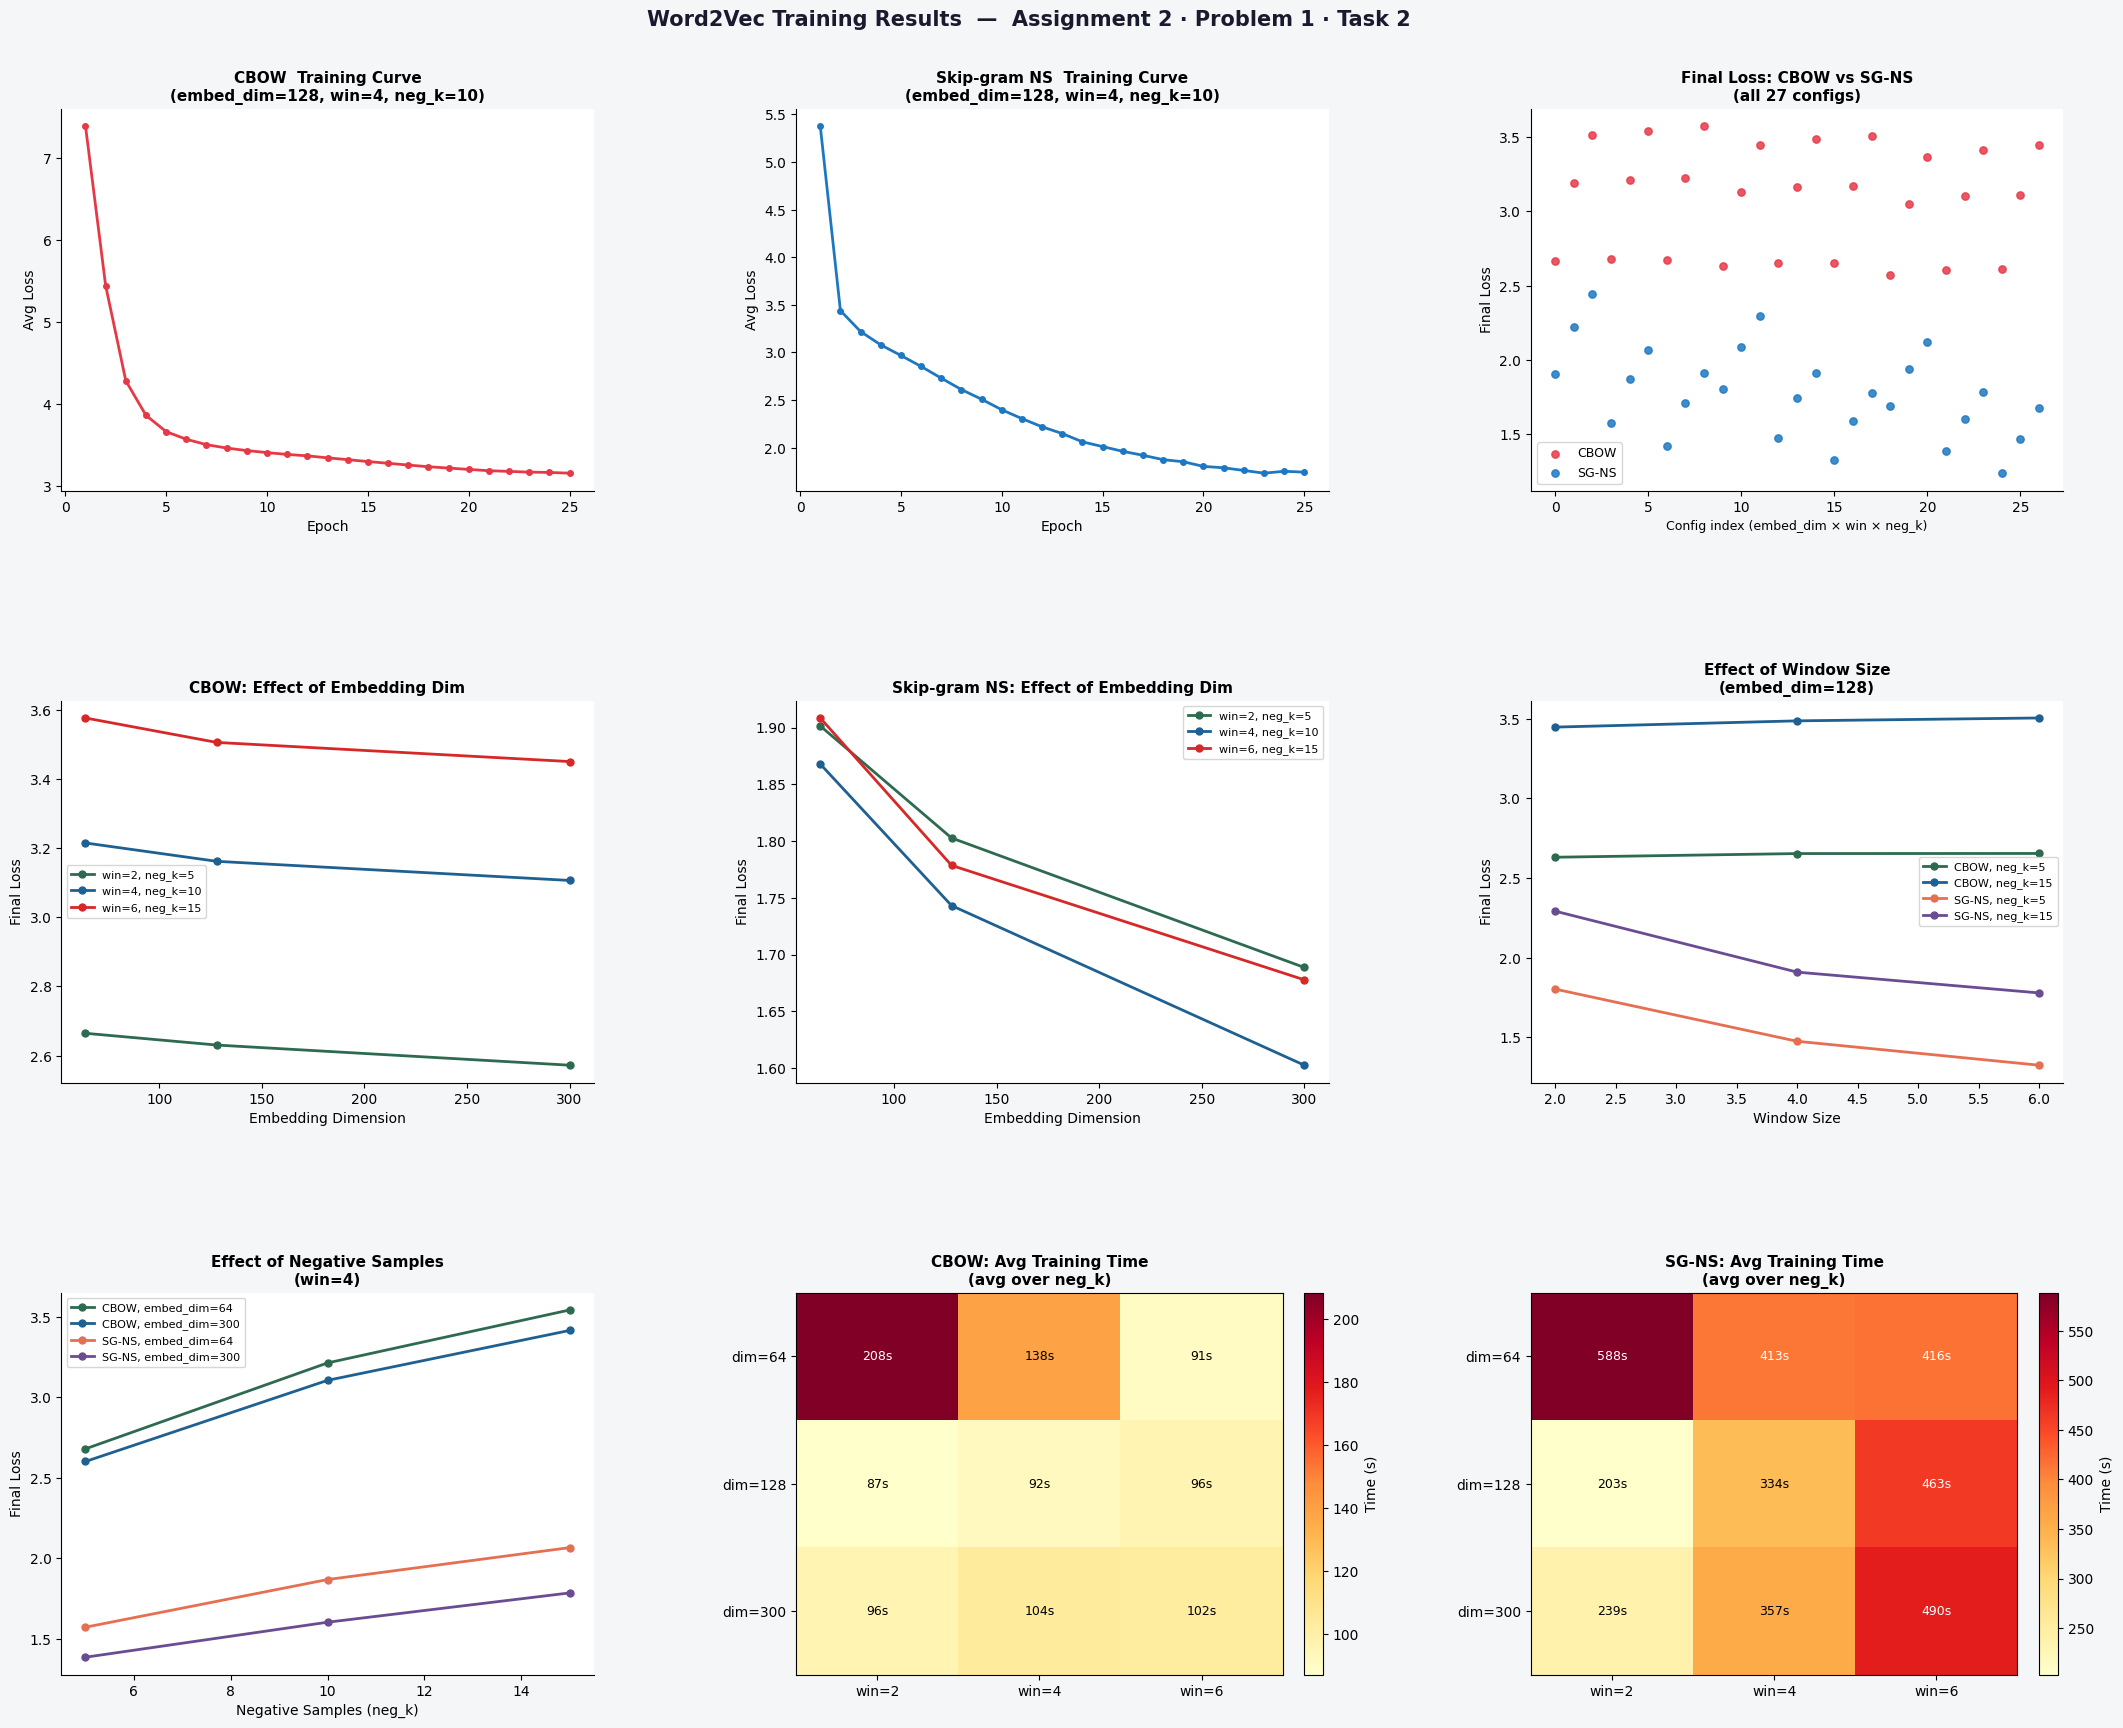

[INFO] Figure saved → word2vec_task2_results.png

[INFO] Best CBOW  config: embed_dim=300, win=2, neg_k=5  →  loss=2.5724
[INFO] Best SG-NS config: embed_dim=300,   win=6,   neg_k=5   →  loss=1.2359

[INFO] Saved → cbow_embeddings.npy
[INFO] Saved → sgns_embeddings.npy
[INFO] Saved → vocab.json

[DONE] Task 2 (scratch models) complete.

  LEARNED EMBEDDING VECTOR PRINTOUT
  Word chosen : 'research'
  Format      : <word> - v1, v2, v3, ..., vN

  [Scratch CBOW | embed_dim=300, win=2, neg_k=5]
  research - -0.1290, 0.0937, 0.0246, -0.1752, 0.0767, 0.0123, -0.0759, -0.0696, -0.0223, -0.0068, 0.0039, -0.0996, -0.0637, -0.0764, -0.1478, -0.0609, -0.0598, 0.0230, -0.0270, -0.0506, 0.0163, 0.0307, -0.1231, -0.1610, -0.1179, 0.0874, 0.0943, -0.0675, 0.0491, 0.1635, 0.0781, -0.0688, 0.0806, -0.0649, 0.0325, -0.0522, 0.1151, 0.0384, -0.1037, 0.0248, -0.0808, 0.2185, 0.0271, 0.0588, 0.0063, 0.0478, 0.0392, -0.0265, -0.0159, 0.1504, 0.0576, 0.0415, 0.1102, -0.0459, -0.1936, 0.0337, 0.0501, 0.0160,

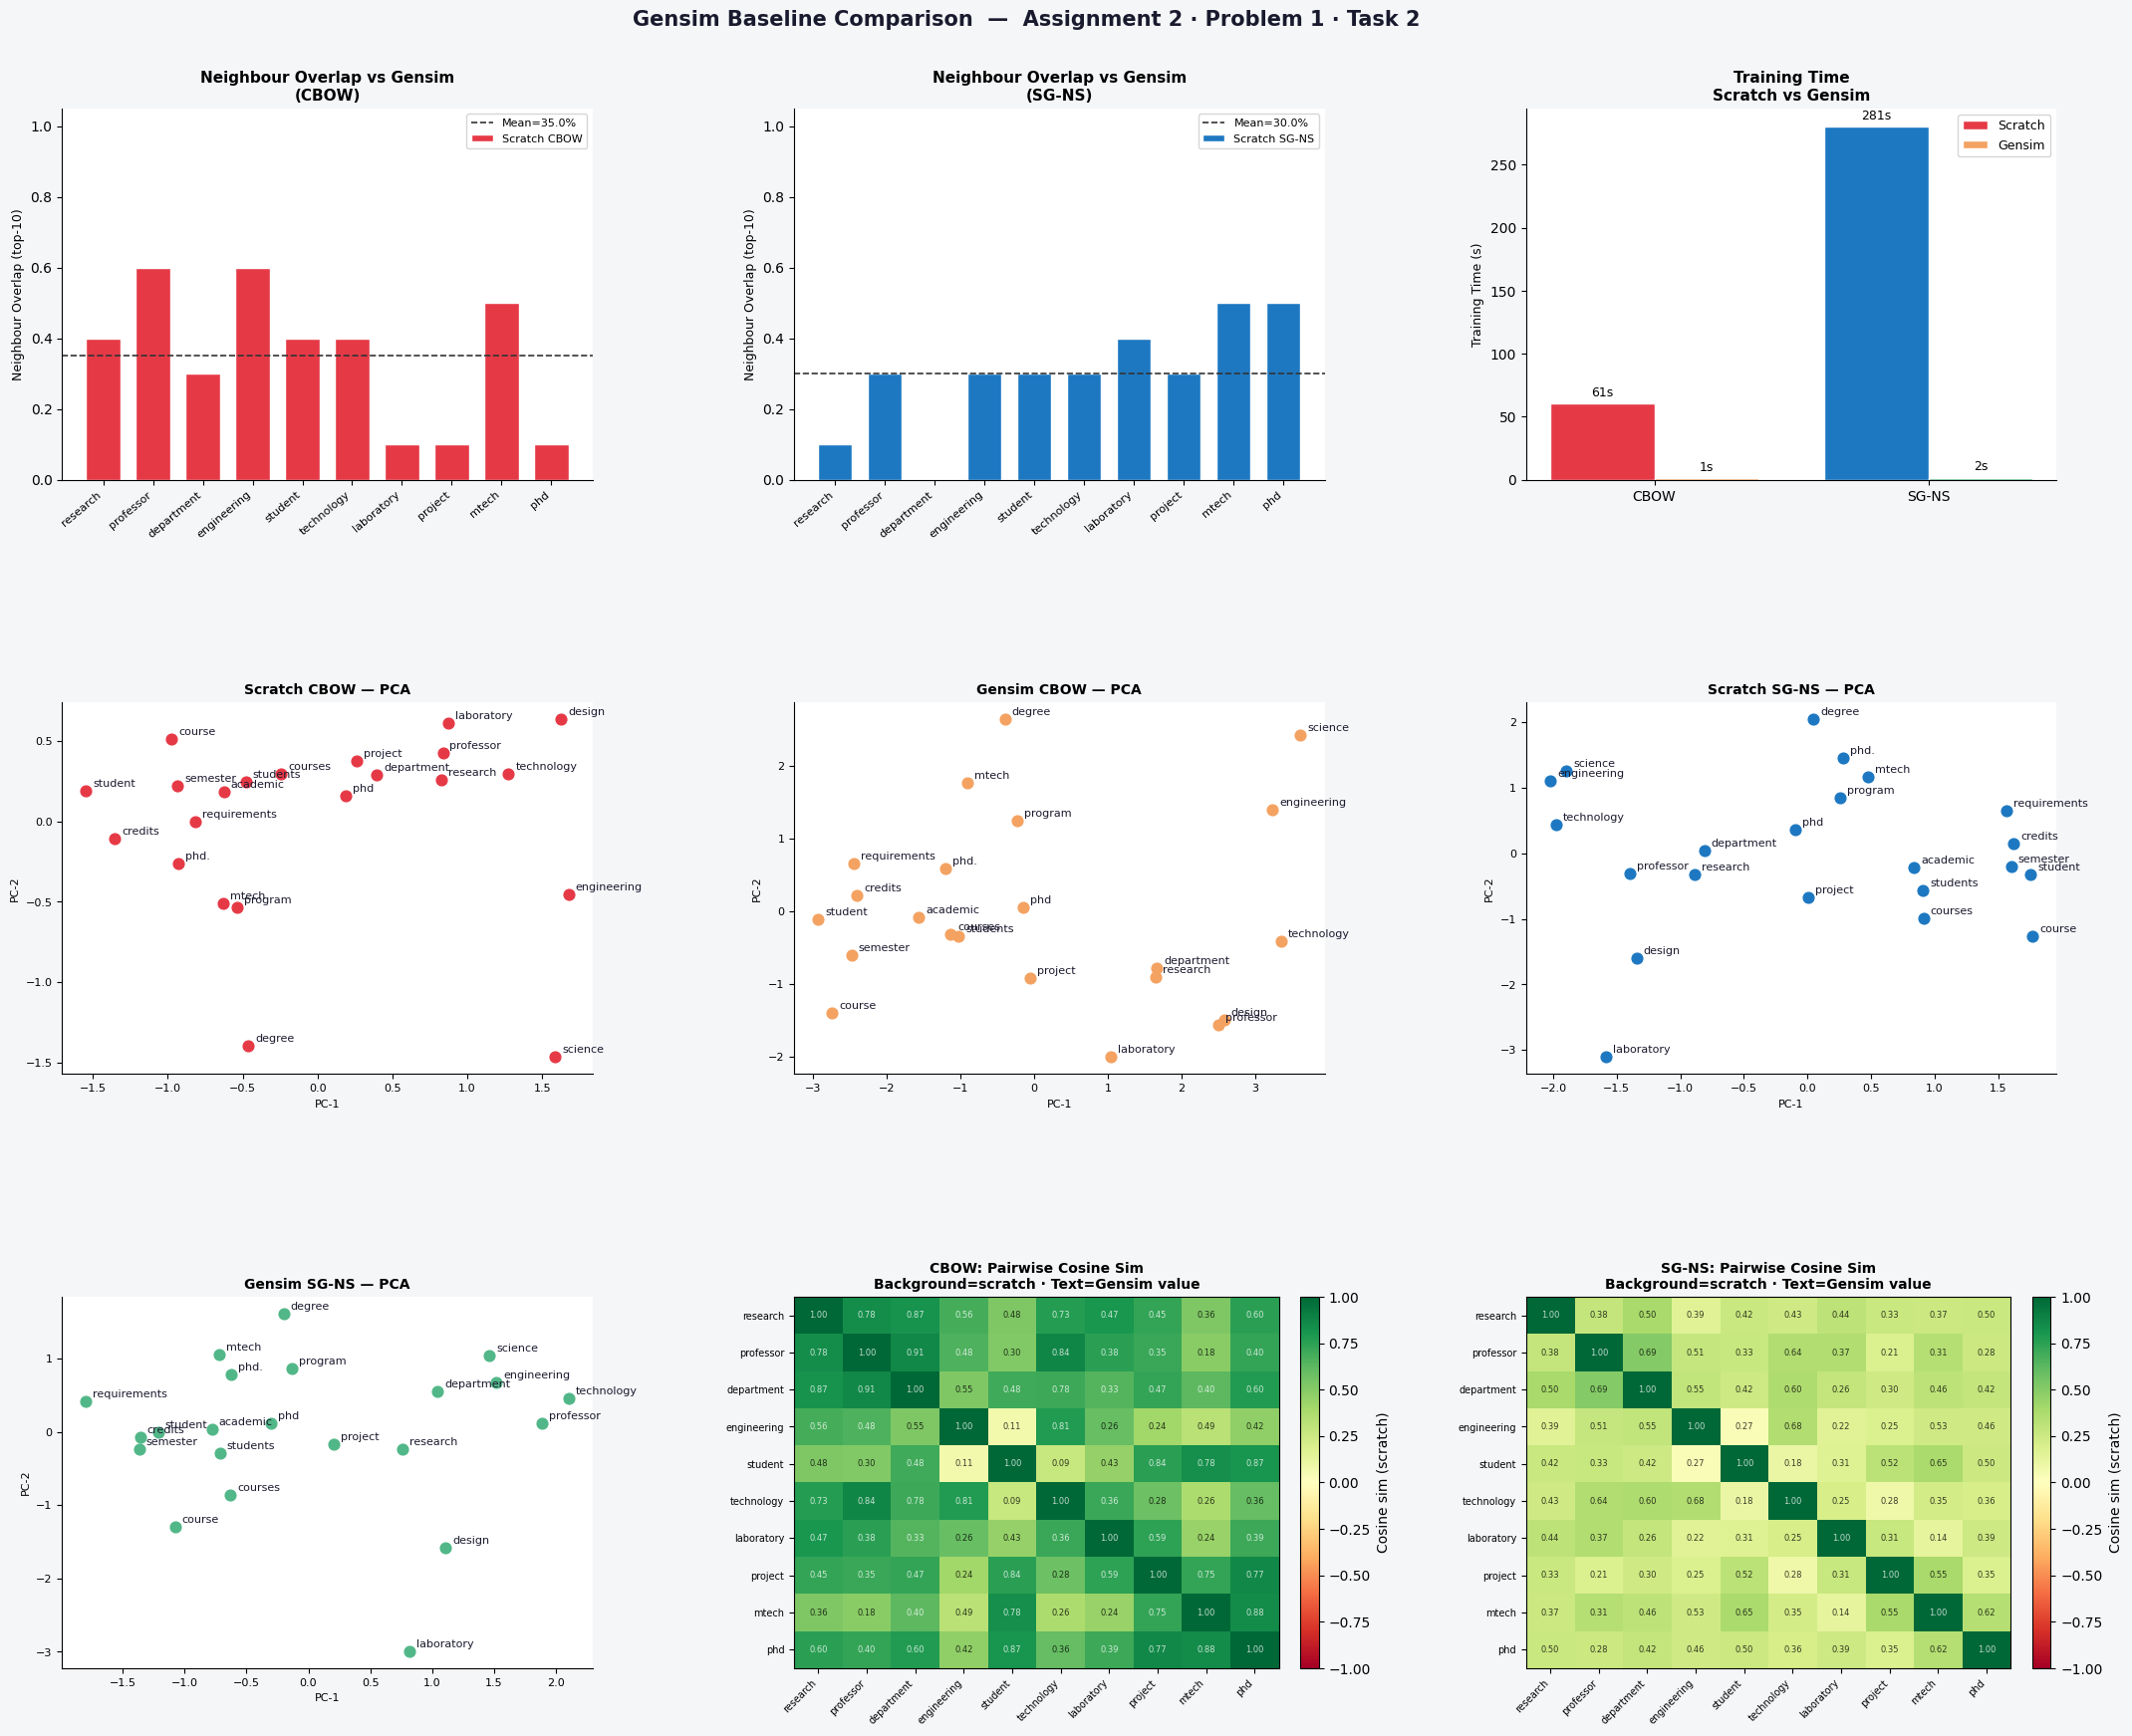

[INFO] Figure saved → gensim_comparison.png
[INFO] Saved → gensim_cbow_vectors.txt
[INFO] Saved → gensim_sg_vectors.txt

[DONE] Task 2 complete (scratch + Gensim comparison).


In [ ]:
from gensim.models import Word2Vec as GensimWord2Vec
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine

RANDOM_SEED = 100
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# CORPUS LOADING & PREPROCESSING
# reusing the same STOP_WORDS, BOILERPLATE_PATTERNS, strip_noise,
# and tokenize_and_filter from Task 1 — everything is already in memory

CORPUS_FILE = "iitj_cleaned_corpus.txt"

# degree abbreviations appear in all sorts of dotted forms in the corpus
# (e.g. "M.Tech.", "m.tech", "M.Tech") - collapse them all to one clean
# token before tokenising so the model doesn't treat them as separate words.
# Task 1 already lowercased every token, so patterns only need to match the lowercase forms here.

DEGREE_NORMALISATION = {
    r'\bm\.tech\.?\b'         : 'mtech',
    r'\bb\.tech\.?\b'         : 'btech',
    r'\bph\.d\.?\b'           : 'phd',
    r'\bm\.sc\.?\b'           : 'msc',
    r'\bb\.sc\.?\b'           : 'bsc',
    r'\bm\.b\.a\.?\b'         : 'mba',
    r'\bm\.e\.?\b'            : 'me',
    r'\bb\.e\.?\b'            : 'be',
    r'\bm\.tech\.-ph\.d\.?\b' : 'mtech-phd',
}

def apply_degree_normalisation(tokens):
    """
    Re-joins a pre-tokenised sentence into a string, applies degree-abbreviation normalisation (the only extra processing Task 2 needs
    on top of what Task 1 already did), then re-splits on whitespace.

    We work on the joined string rather than token-by-token because patterns like 'm.tech' span a single surface form that word_tokenize
    may have already split at the dots — re-joining lets the regex match the whole abbreviation correctly.
    """
    text = ' '.join(tokens)
    for pattern, replacement in DEGREE_NORMALISATION.items():
        text = re.sub(pattern, replacement, text)
    return text.split()


# Loading the cleaned corpus produced by Task 1.
# Each line is a space-separated token sequence - no further noise-stripping
# or re-tokenisation is needed; we only apply degree normalisation on top.
print("Loading cleaned corpus …")
all_sentences = []
with open(CORPUS_FILE, 'r', encoding='utf-8') as fh:
    for line in fh:
        tokens = line.strip().split()
        if len(tokens) >= 5:
            tokens = apply_degree_normalisation(tokens)
            all_sentences.append(tokens)

# flatten into one big token list for frequency counting
flat_token_list = [tok for sent in all_sentences for tok in sent]

print(f"[INFO] Sentences : {len(all_sentences):,}")
print(f"[INFO] Tokens    : {len(flat_token_list):,}")

# VOCABULARY
# MIN_COUNT = 1 keeps every word - gives the model broader coverage of
# rare domain-specific terms like professor names and department codes

MIN_WORD_COUNT = 1

token_freq  = Counter(flat_token_list)
vocab       = sorted([w for w, cnt in token_freq.items() if cnt >= MIN_WORD_COUNT])
word_to_idx = {w: i for i, w in enumerate(vocab)}
idx_to_word = {i: w for w, i in word_to_idx.items()}
vocab_size  = len(vocab)

print(f"[INFO] Vocabulary size (min_count={MIN_WORD_COUNT}): {vocab_size:,}")

# dropping any tokens that didn't make the vocab cut, and remove sentences that are now too short to form any useful training pairs
all_sentences = [[w for w in sent if w in word_to_idx] for sent in all_sentences]
all_sentences = [sent for sent in all_sentences if len(sent) >= 2]

# SUBSAMPLING OF FREQUENT WORDS
# Words are discarded with probability P(w) = 1 - sqrt(t / f(w))
# where f(w) is the relative frequency and t = 1e-4 is the threshold.
# Same formula as the original Word2Vec paper - makes the model pay more attention to rarer, more informative words.

# words appearing more often than roughly 1-in-10,000 tokens start getting dropped
SUBSAMPLE_THRESHOLD  = 1e-4
corpus_total_tokens  = len(flat_token_list)


def keep_token(word):
    """
    Returns True if this word should survive into the training sentence.
    High-frequency words get dropped more aggressively; rare words almost never.
    """
    relative_freq    = token_freq[word] / corpus_total_tokens
    # keep probability from the paper — can exceed 1.0 for very rare words, which is fine since random() < 1 is always True
    keep_probability = math.sqrt(SUBSAMPLE_THRESHOLD / relative_freq)
    return random.random() < keep_probability


def apply_subsampling(sentence_list):
    """
    Runs keep_token on every word in every sentence independently.
    Sentences that shrink below 2 words after filtering are dropped entirely.
    """
    result = []
    for sent in sentence_list:
        filtered = [w for w in sent if keep_token(w)]
        if len(filtered) >= 2:
            result.append(filtered)
    return result

# NEGATIVE-SAMPLING TABLE  (unigram distribution raised to 3/4)
# Pre-building a large lookup array is much faster than recomputing the full distribution every time we need a negative sample 
# same trick used in the original Word2Vec implementation.

def build_negative_sample_table(table_size=1_000_000):
    """
    Fills a big array with vocab indices sampled proportional to freq(w)^0.75.
    The 3/4 power smoothing means common words are sampled a bit less often
    and rare words get a slightly higher chance — helps with training stability.
    """
    raw_counts  = np.array([token_freq.get(idx_to_word[i], 0)
                             for i in range(vocab_size)], dtype=np.float64)
    smoothed    = raw_counts ** 0.75
    noise_probs = smoothed / smoothed.sum()   # normalise to a proper distribution

    return np.random.choice(vocab_size, size=table_size, p=noise_probs).astype(np.int32)

NOISE_TABLE = build_negative_sample_table()

def draw_negatives(positive_idx, num_samples):
    """
    Pulls num_samples negative indices from the noise table,
    skipping any that accidentally match the positive target.
    """
    negatives = []
    while len(negatives) < num_samples:
        candidate = NOISE_TABLE[random.randint(0, len(NOISE_TABLE) - 1)]
        if candidate != positive_idx:
            negatives.append(candidate)
    return negatives

# SIGMOID HELPER

def stable_sigmoid(x):
    """
    Numerically stable sigmoid — avoids overflow for large |x| by choosing
    the form of the expression based on the sign of x.
    """
    return np.where(
        x >= 0,
        1.0 / (1.0 + np.exp(-x)),
        np.exp(x) / (1.0 + np.exp(x))
    )

# WORD2VEC BASE CLASS
# Shared by both CBOW and Skip-gram - holds the embedding matrices,the negative-sampling loss computation, and the nearest-neighbour lookup.

class Word2Vec:
    """
    input_embeddings  (V x embed_dim) — the actual trained word vectors
    output_embeddings (V x embed_dim) — context/output matrix used only during training

    Both are initialised with Xavier uniform; output starts at zero.
    That asymmetry helps avoid degenerate solutions early in training.
    """

    def __init__(self, vocab_size, embed_dim, window_size, num_negatives,
                 learning_rate=0.05, min_learning_rate=0.001):

        self.vocab_size       = vocab_size
        self.embed_dim        = embed_dim
        self.window_size      = window_size
        self.num_negatives    = num_negatives
        self.learning_rate    = learning_rate
        self.min_learning_rate = min_learning_rate

        # Xavier uniform keeps initial dot products in a reasonable range - matters more here than in deep nets since there's no batch norm
        xavier_limit = math.sqrt(6.0 / (vocab_size + embed_dim))
        self.input_embeddings  = np.random.uniform(
            -xavier_limit, xavier_limit, (vocab_size, embed_dim)
        )
        self.output_embeddings = np.zeros((vocab_size, embed_dim))

        self.epoch_losses = []   # one entry per epoch
        self.train_time   = 0.0  # wall-clock seconds for the full run

    def _ns_loss_and_grads(self, hidden_vec, positive_idx, negative_idxs):
        """
        Negative-sampling loss for one (center, context) pair:
            Loss = -log σ(v_pos · h) - Σ_k log σ(-v_neg_k · h)

        Returns the scalar loss plus gradients for h, v_pos, and each v_neg.
        """
        h     = hidden_vec
        v_pos = self.output_embeddings[positive_idx]

        # positive sample — we want this score close to 1
        pos_score  = stable_sigmoid(np.dot(v_pos, h))
        loss       = -np.log(pos_score + 1e-10)
        grad_h     = (pos_score - 1.0) * v_pos
        grad_pos   = (pos_score - 1.0) * h

        # negative samples - we want each of these scores close to 0
        grad_negs = []
        for neg_idx in negative_idxs:
            v_neg     = self.output_embeddings[neg_idx]
            neg_score = stable_sigmoid(np.dot(v_neg, h))
            loss     += -np.log(1.0 - neg_score + 1e-10)
            grad_h   += neg_score * v_neg
            grad_negs.append(neg_score * h)

        return loss, grad_h, grad_pos, grad_negs

    def get_word_vector(self, word):
        # just a convenience wrapper - returns a copy so callers can't mutate the matrix
        return self.input_embeddings[word_to_idx[word]].copy()

    def get_nearest_neighbours(self, query_word, top_n=5):
        """
        Cosine similarity lookup - same approach as Task 3 but living here
        on the model object so it's easy to call during debugging.
        """
        if query_word not in word_to_idx:
            return []
        query_vec  = self.input_embeddings[word_to_idx[query_word]]
        row_norms  = np.linalg.norm(self.input_embeddings, axis=1) + 1e-10
        query_norm = np.linalg.norm(query_vec) + 1e-10
        cosine_sims = (self.input_embeddings @ query_vec) / (row_norms * query_norm)

        # masking out the query word so it doesn't appear in its own neighbour list
        cosine_sims[word_to_idx[query_word]] = -1.0
        top_indices = np.argsort(-cosine_sims)[:top_n]
        return [(idx_to_word[i], float(cosine_sims[i])) for i in top_indices]

# CBOW MODEL

class CBOW(Word2Vec):
    """
    Continuous Bag of Words with Negative Sampling.

    For each target word at position i:
      1. Sample a dynamic window size w' ~ Uniform(1, self.window_size)
      2. Collect the surrounding context word indices
      3. Hidden vector h = mean of their input embeddings
      4. Run NS loss predicting the target from h
      5. Gradient flows back through the mean equally to every context word
    """

    def run_training(self, sentence_list, num_epochs=20, verbose=True):

        start_time      = time.time()
        total_processed = 0   # cumulative word count used for LR decay

        for epoch in range(1, num_epochs + 1):
            epoch_loss  = 0.0
            epoch_words = 0

            # re-subsample every epoch so the model sees a different subset
            # of high-frequency words on each pass through the corpus
            epoch_sentences  = apply_subsampling(sentence_list)
            words_this_epoch = sum(len(s) for s in epoch_sentences)
            random.shuffle(epoch_sentences)

            for sent in epoch_sentences:
                sent_len = len(sent)
                # linearly decay LR over the full run, floored at min_learning_rate
                progress   = total_processed / max(words_this_epoch * num_epochs, 1)
                current_lr = max(self.learning_rate * (1.0 - progress), self.min_learning_rate)

                for i, target_word in enumerate(sent):
                    if target_word not in word_to_idx:
                        continue
                    target_idx = word_to_idx[target_word]

                    # dynamic window gives closer words a higher effective sampling probability over the course of training
                    actual_window = random.randint(1, self.window_size)
                    context_idxs  = [
                        word_to_idx[sent[j]]
                        for j in range(max(0, i - actual_window),
                                       min(sent_len, i + actual_window + 1))
                        if j != i and sent[j] in word_to_idx
                    ]
                    if not context_idxs:
                        continue

                    # CBOW hidden layer is just the mean of context vectors
                    hidden_vec = self.input_embeddings[context_idxs].mean(axis=0)
                    neg_idxs   = draw_negatives(target_idx, self.num_negatives)
                    loss, grad_h, grad_pos, grad_negs = self._ns_loss_and_grads(
                        hidden_vec, target_idx, neg_idxs
                    )

                    epoch_loss  += loss
                    epoch_words += 1

                    # update output matrix for positive and negative words
                    self.output_embeddings[target_idx] -= current_lr * grad_pos
                    for neg_idx, grad_neg in zip(neg_idxs, grad_negs):
                        self.output_embeddings[neg_idx] -= current_lr * grad_neg

                    # gradient flows back through the mean equally to every context word
                    grad_per_context = grad_h / len(context_idxs)
                    for ctx_idx in context_idxs:
                        self.input_embeddings[ctx_idx] -= current_lr * grad_per_context

                    total_processed += 1

            avg_epoch_loss = epoch_loss / max(epoch_words, 1)
            self.epoch_losses.append(avg_epoch_loss)

            if verbose:
                print(f"  [CBOW  D={self.embed_dim:>3} W={self.window_size} K={self.num_negatives}] "
                      f"Epoch {epoch:>2}/{num_epochs}  Loss={avg_epoch_loss:.4f}  LR={current_lr:.6f}")

        self.train_time = time.time() - start_time

# SKIP-GRAM WITH NEGATIVE SAMPLING

class SkipGram(Word2Vec):
    """
    Skip-gram with Negative Sampling.

    For each centre word at position i:
      1. Sample a dynamic window size w' ~ Uniform(1, self.window_size)
      2. For each context word in the window, run NS loss using the center
         word's embedding as the hidden vector
      3. Accumulate gradients across all context words, then write back to
         input_embeddings[center] exactly once — avoids redundant read/writes
         when the window is large
    """

    def run_training(self, sentence_list, num_epochs=20, verbose=True):

        start_time      = time.time()
        total_processed = 0

        for epoch in range(1, num_epochs + 1):
            epoch_loss  = 0.0
            epoch_pairs = 0   # counting (center, context) pairs, not individual words

            epoch_sentences  = apply_subsampling(sentence_list)
            words_this_epoch = sum(len(s) for s in epoch_sentences)
            random.shuffle(epoch_sentences)

            for sent in epoch_sentences:
                sent_len   = len(sent)
                progress   = total_processed / max(words_this_epoch * num_epochs, 1)
                current_lr = max(self.learning_rate * (1.0 - progress), self.min_learning_rate)

                for i, center_word in enumerate(sent):
                    if center_word not in word_to_idx:
                        continue
                    center_idx  = word_to_idx[center_word]
                    center_vec  = self.input_embeddings[center_idx].copy()

                    # accumulate gradients across all context words before writing back -  single write per centre word keeps the inner loop clean
                    accumulated_grad = np.zeros(self.embed_dim)

                    actual_window = random.randint(1, self.window_size)
                    for j in range(max(0, i - actual_window),
                                   min(sent_len, i + actual_window + 1)):
                        if j == i:
                            continue
                        context_word = sent[j]
                        if context_word not in word_to_idx:
                            continue
                        context_idx = word_to_idx[context_word]

                        neg_idxs = draw_negatives(context_idx, self.num_negatives)
                        loss, grad_center, grad_pos, grad_negs = self._ns_loss_and_grads(
                            center_vec, context_idx, neg_idxs
                        )

                        epoch_loss  += loss
                        epoch_pairs += 1

                        # update output matrix immediately for each context word
                        self.output_embeddings[context_idx] -= current_lr * grad_pos
                        for neg_idx, grad_neg in zip(neg_idxs, grad_negs):
                            self.output_embeddings[neg_idx] -= current_lr * grad_neg

                        accumulated_grad += grad_center

                    # apply the accumulated gradient to the centre word once
                    self.input_embeddings[center_idx] -= current_lr * accumulated_grad
                    total_processed += 1

            avg_epoch_loss = epoch_loss / max(epoch_pairs, 1)
            self.epoch_losses.append(avg_epoch_loss)

            if verbose:
                print(f"  [SG-NS D={self.embed_dim:>3} W={self.window_size} K={self.num_negatives}] "
                      f"Epoch {epoch:>2}/{num_epochs}  Loss={avg_epoch_loss:.4f}  LR={current_lr:.6f}")

        self.train_time = time.time() - start_time

# EXPERIMENT GRID
# Loop variables use full names (embed_dim / win / neg_k) rather than single letters to avoid accidentally shadowing vocab_size V in
# Jupyter's global namespace - that caused a KeyError during development.

EMBEDDING_DIMS    = [64, 128, 300]
WINDOW_SIZES      = [2, 4, 6]
NEG_SAMPLE_COUNTS = [5, 10, 15]

NUM_EPOCHS = 25     # enough epochs for the loss to clearly plateau
INIT_LR    = 0.05   # slightly higher than the baseline 0.025 for faster initial descent
FLOOR_LR   = 0.001  # raised floor so updates don't become negligibly small late in training

# quick sanity check — caught a KeyError during development when vocab_size
# happened to equal one of the embedding dims
assert vocab_size not in EMBEDDING_DIMS, (
    f"vocab_size={vocab_size} collides with an EMBEDDING_DIMS value — remove it.")

trained_models = {}   # (model_type, embed_dim, win, neg_k) → trained model

total_configs = len(EMBEDDING_DIMS) * len(WINDOW_SIZES) * len(NEG_SAMPLE_COUNTS)
print(f"\n[INFO] Grid: {total_configs} configs × 2 models = {total_configs * 2} runs")
print(f"[INFO] EMBEDDING_DIMS={EMBEDDING_DIMS}, WINDOW_SIZES={WINDOW_SIZES}, NEG_SAMPLE_COUNTS={NEG_SAMPLE_COUNTS}")
print(f"[INFO] NUM_EPOCHS={NUM_EPOCHS}, INIT_LR={INIT_LR}, FLOOR_LR={FLOOR_LR}, "
      f"SUBSAMPLE_THRESHOLD={SUBSAMPLE_THRESHOLD}\n")

run_counter = 0
for embed_dim, win, neg_k in itertools.product(EMBEDDING_DIMS, WINDOW_SIZES, NEG_SAMPLE_COUNTS):
    run_counter += 1
    print(f"── Config {run_counter}/{total_configs}: "
          f"embed_dim={embed_dim}, win={win}, neg_k={neg_k} ──")

    cbow_model = CBOW(vocab_size, embed_dim, win, neg_k,
                      learning_rate=INIT_LR, min_learning_rate=FLOOR_LR)
    cbow_model.run_training(all_sentences, num_epochs=NUM_EPOCHS, verbose=True)
    trained_models[('cbow', embed_dim, win, neg_k)] = cbow_model

    # train skip-gram on the same config so the two are directly comparable
    sg_model = SkipGram(vocab_size, embed_dim, win, neg_k,
                        learning_rate=INIT_LR, min_learning_rate=FLOOR_LR)
    sg_model.run_training(all_sentences, num_epochs=NUM_EPOCHS, verbose=True)
    trained_models[('sgns', embed_dim, win, neg_k)] = sg_model

    print()

print("[INFO] All models trained.\n")

# making sure every expected key landed in the dict before anything downstream tries to read it
for model_type in ('cbow', 'sgns'):
    for embed_dim, win, neg_k in itertools.product(EMBEDDING_DIMS, WINDOW_SIZES, NEG_SAMPLE_COUNTS):
        key = (model_type, embed_dim, win, neg_k)
        assert key in trained_models, f"[BUG] Missing key {key}"
print("[INFO] Integrity check passed.\n")

# RESULTS TABLE

print("=" * 80)
print(f"{'Model':<8} {'EmbDim':>7} {'Win':>5} {'NegK':>5}  {'FinalLoss':>10}  {'Time(s)':>9}")
print("=" * 80)
for (model_type, embed_dim, win, neg_k), model in sorted(trained_models.items()):
    display_name = "CBOW" if model_type == 'cbow' else "SG-NS"
    print(f"{display_name:<8} {embed_dim:>7} {win:>5} {neg_k:>5}  "
          f"{model.epoch_losses[-1]:>10.4f}  {model.train_time:>9.1f}")
print("=" * 80)

# VISUALISATION

# pull grid values back out of the results dict rather than hardcoding them - this way the plots stay correct if the grid changes between runs
EMBEDDING_DIMS    = sorted(set(k[1] for k in trained_models.keys()))
WINDOW_SIZES      = sorted(set(k[2] for k in trained_models.keys()))
NEG_SAMPLE_COUNTS = sorted(set(k[3] for k in trained_models.keys()))

# middle value of each axis as the "representative" config for the loss curves
rep_embed_dim = EMBEDDING_DIMS[1]      # 128
rep_window    = WINDOW_SIZES[1]        # 4
rep_neg_k     = NEG_SAMPLE_COUNTS[1]   # 10

CBOW_PLOT_COLOR = '#e63946'
SGNS_PLOT_COLOR = '#1d78c1'
LINE_PALETTE    = ['#2d6a4f', '#1e6091', '#d62828', '#e76f51', '#6a4c93',
                   '#f4a261', '#168aad', '#52b788', '#9b5de5']

fig = plt.figure(figsize=(22, 18))
fig.patch.set_facecolor('#f4f6f8')
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38,
                        top=0.92, bottom=0.05, left=0.06, right=0.97)

# Row 0, cols 0-1: Training loss curves for the representative config
ax_cbow_curve = fig.add_subplot(gs[0, 0])
ax_sg_curve   = fig.add_subplot(gs[0, 1])

for ax, model_type, color, label in [
        (ax_cbow_curve, 'cbow', CBOW_PLOT_COLOR, 'CBOW'),
        (ax_sg_curve,   'sgns', SGNS_PLOT_COLOR, 'Skip-gram NS')]:
    model = trained_models[(model_type, rep_embed_dim, rep_window, rep_neg_k)]
    ax.plot(range(1, NUM_EPOCHS + 1), model.epoch_losses, 'o-',
            color=color, linewidth=2, markersize=4)
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('Avg Loss', fontsize=10)
    ax.set_title(f'{label}  Training Curve\n'
                 f'(embed_dim={rep_embed_dim}, win={rep_window}, neg_k={rep_neg_k})',
                 fontsize=11, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

# Row 0, col 2: Scatter of final loss across all 27 configs
ax_scatter = fig.add_subplot(gs[0, 2])
cbow_final_losses = [
    trained_models[('cbow', ed, w, k)].epoch_losses[-1]
    for ed, w, k in itertools.product(EMBEDDING_DIMS, WINDOW_SIZES, NEG_SAMPLE_COUNTS)
]

sg_final_losses = [
    trained_models[('sgns', ed, w, k)].epoch_losses[-1]
    for ed, w, k in itertools.product(EMBEDDING_DIMS, WINDOW_SIZES, NEG_SAMPLE_COUNTS)
]

ax_scatter.scatter(range(len(cbow_final_losses)), cbow_final_losses,
                   color=CBOW_PLOT_COLOR, label='CBOW',  s=28, alpha=0.85, zorder=3)

ax_scatter.scatter(range(len(sg_final_losses)),   sg_final_losses,
                   color=SGNS_PLOT_COLOR, label='SG-NS', s=28, alpha=0.85, zorder=3)
ax_scatter.set_xlabel('Config index (embed_dim × win × neg_k)', fontsize=9)

ax_scatter.set_ylabel('Final Loss', fontsize=10)
ax_scatter.set_title('Final Loss: CBOW vs SG-NS\n(all 27 configs)', fontsize=11, fontweight='bold')
ax_scatter.legend(fontsize=9)
ax_scatter.spines[['top', 'right']].set_visible(False)

# Row 1, cols 0-1: Effect of embedding dimension on final loss
for col_idx, (model_type, color, label) in enumerate([
        ('cbow', CBOW_PLOT_COLOR, 'CBOW'),
        ('sgns', SGNS_PLOT_COLOR, 'Skip-gram NS')]):
    ax = fig.add_subplot(gs[1, col_idx])
    # three representative (win, neg_k) combos to show the trend isn't a fluke
    for line_idx, (w, k) in enumerate([(2, 5), (4, 10), (6, 15)]):
        final_losses = [
            trained_models[(model_type, ed, w, k)].epoch_losses[-1]
            for ed in EMBEDDING_DIMS
        ]
        ax.plot(EMBEDDING_DIMS, final_losses, 'o-', color=LINE_PALETTE[line_idx],
                label=f'win={w}, neg_k={k}', linewidth=2, markersize=5)
    ax.set_xlabel('Embedding Dimension', fontsize=10)
    ax.set_ylabel('Final Loss', fontsize=10)
    ax.set_title(f'{label}: Effect of Embedding Dim', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

# Row 1, col 2: Effect of window size (both models, min and max neg_k)
ax_win = fig.add_subplot(gs[1, 2])
for i, (model_type, label) in enumerate([('cbow', 'CBOW'), ('sgns', 'SG-NS')]):
    for j, k in enumerate([NEG_SAMPLE_COUNTS[0], NEG_SAMPLE_COUNTS[-1]]):
        final_losses = [
            trained_models[(model_type, EMBEDDING_DIMS[1], w, k)].epoch_losses[-1]
            for w in WINDOW_SIZES
        ]
        ax_win.plot(WINDOW_SIZES, final_losses, 'o-', color=LINE_PALETTE[i * 3 + j],
                    label=f'{label}, neg_k={k}', linewidth=2, markersize=5)
ax_win.set_xlabel('Window Size', fontsize=10)
ax_win.set_ylabel('Final Loss', fontsize=10)
ax_win.set_title(f'Effect of Window Size\n(embed_dim={EMBEDDING_DIMS[1]})',
                 fontsize=11, fontweight='bold')
ax_win.legend(fontsize=8)
ax_win.spines[['top', 'right']].set_visible(False)

# Row 2, col 0: Effect of negative sample count on final loss
ax_neg = fig.add_subplot(gs[2, 0])
for i, (model_type, label) in enumerate([('cbow', 'CBOW'), ('sgns', 'SG-NS')]):
    for j, ed in enumerate([EMBEDDING_DIMS[0], EMBEDDING_DIMS[-1]]):
        final_losses = [
            trained_models[(model_type, ed, WINDOW_SIZES[1], k)].epoch_losses[-1]
            for k in NEG_SAMPLE_COUNTS
        ]
        ax_neg.plot(NEG_SAMPLE_COUNTS, final_losses, 'o-', color=LINE_PALETTE[i * 3 + j],
                    label=f'{label}, embed_dim={ed}', linewidth=2, markersize=5)
ax_neg.set_xlabel('Negative Samples (neg_k)', fontsize=10)
ax_neg.set_ylabel('Final Loss', fontsize=10)
ax_neg.set_title(f'Effect of Negative Samples\n(win={WINDOW_SIZES[1]})',
                 fontsize=11, fontweight='bold')
ax_neg.legend(fontsize=8)
ax_neg.spines[['top', 'right']].set_visible(False)

# Row 2, cols 1-2: Heatmaps of average training time
for col_idx, (model_type, label) in enumerate([('cbow', 'CBOW'), ('sgns', 'SG-NS')]):
    ax = fig.add_subplot(gs[2, col_idx + 1])
    # average over the neg_k axis to get a clean 2D slice — training time
    # doesn't vary much with neg_k compared to embed_dim and window size
    time_matrix = np.zeros((len(EMBEDDING_DIMS), len(WINDOW_SIZES)))
    for di, ed in enumerate(EMBEDDING_DIMS):
        for wi, w in enumerate(WINDOW_SIZES):
            time_matrix[di, wi] = np.mean([
                trained_models[(model_type, ed, w, k)].train_time
                for k in NEG_SAMPLE_COUNTS
            ])
    im = ax.imshow(time_matrix, aspect='auto', cmap='YlOrRd')
    ax.set_xticks(range(len(WINDOW_SIZES)))
    ax.set_xticklabels([f'win={w}' for w in WINDOW_SIZES])
    ax.set_yticks(range(len(EMBEDDING_DIMS)))
    ax.set_yticklabels([f'dim={ed}' for ed in EMBEDDING_DIMS])
    plt.colorbar(im, ax=ax, label='Time (s)', fraction=0.046, pad=0.04)
    for di in range(len(EMBEDDING_DIMS)):
        for wi in range(len(WINDOW_SIZES)):
            # white text on dark cells so it stays readable
            text_color = 'black' if time_matrix[di, wi] < time_matrix.max() * 0.7 else 'white'
            ax.text(wi, di, f'{time_matrix[di, wi]:.0f}s',
                    ha='center', va='center', fontsize=9, color=text_color)
    ax.set_title(f'{label}: Avg Training Time\n(avg over neg_k)',
                 fontsize=11, fontweight='bold')

fig.suptitle('Word2Vec Training Results  —  Assignment 2 · Problem 1 · Task 2',
             fontsize=15, fontweight='bold', y=0.975, color='#1a1a2e')

plt.savefig('word2vec_task2_results.png', dpi=130,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("[INFO] Figure saved → word2vec_task2_results.png")

# SAVE BEST MODELS

def find_best_config(model_type):
    """Picks the (embed_dim, win, neg_k) combo with the lowest final-epoch loss."""
    return min(
        itertools.product(EMBEDDING_DIMS, WINDOW_SIZES, NEG_SAMPLE_COUNTS),
        key=lambda cfg: trained_models[(model_type, *cfg)].epoch_losses[-1]
    )

best_cbow_config = find_best_config('cbow')
best_sg_config   = find_best_config('sgns')

print(f"\n[INFO] Best CBOW  config: embed_dim={best_cbow_config[0]}, win={best_cbow_config[1]}, "
      f"neg_k={best_cbow_config[2]}  →  loss={trained_models[('cbow', *best_cbow_config)].epoch_losses[-1]:.4f}")
print(f"[INFO] Best SG-NS config: embed_dim={best_sg_config[0]},   win={best_sg_config[1]},   "
      f"neg_k={best_sg_config[2]}   →  loss={trained_models[('sgns', *best_sg_config)].epoch_losses[-1]:.4f}")

# save embeddings and vocab so Tasks 3 and 4 can load them without retraining
best_cbow_model = trained_models[('cbow', *best_cbow_config)]
best_sg_model   = trained_models[('sgns', *best_sg_config)]

np.save('cbow_embeddings.npy', best_cbow_model.input_embeddings)
np.save('sgns_embeddings.npy', best_sg_model.input_embeddings)

with open('vocab.json', 'w') as vocab_file:
    json.dump({
        'word2idx': word_to_idx,
        'idx2word': {str(k): v for k, v in idx_to_word.items()}
    }, vocab_file)

print("\n[INFO] Saved → cbow_embeddings.npy")
print("[INFO] Saved → sgns_embeddings.npy")
print("[INFO] Saved → vocab.json")
print("\n[DONE] Task 2 (scratch models) complete.")

# EMBEDDING VECTOR PRINTOUT  (scratch models)

# Prints the full learned embedding for a chosen vocabulary word from each trained model in the specified comma-separated format

VECTOR_PRINT_WORD = 'research'

def _fmt_vector(vec):
    """Formats a 1-D numpy array as a comma-separated string of 4-d.p. values."""
    return ", ".join(f"{v:.4f}" for v in vec)

print("\n" + "=" * 72)
print("  LEARNED EMBEDDING VECTOR PRINTOUT")
print(f"  Word chosen : '{VECTOR_PRINT_WORD}'")
print("  Format      : <word> - v1, v2, v3, ..., vN")
print("=" * 72)

# Scratch CBOW 
if VECTOR_PRINT_WORD in word_to_idx:
    sc_cbow_vec = best_cbow_model.input_embeddings[word_to_idx[VECTOR_PRINT_WORD]]
    print(f"\n  [Scratch CBOW | embed_dim={best_cbow_model.embed_dim}, "
          f"win={best_cbow_model.window_size}, neg_k={best_cbow_model.num_negatives}]")
    print(f"  {VECTOR_PRINT_WORD} - {_fmt_vector(sc_cbow_vec)}")
else:
    print(f"\n  [Scratch CBOW] '{VECTOR_PRINT_WORD}' is OOV — not found in vocabulary.")

# Scratch SG-NS
if VECTOR_PRINT_WORD in word_to_idx:
    sc_sg_vec = best_sg_model.input_embeddings[word_to_idx[VECTOR_PRINT_WORD]]
    print(f"\n  [Scratch SG-NS | embed_dim={best_sg_model.embed_dim}, "
          f"win={best_sg_model.window_size}, neg_k={best_sg_model.num_negatives}]")
    print(f"  {VECTOR_PRINT_WORD} - {_fmt_vector(sc_sg_vec)}")
else:
    print(f"\n  [Scratch SG-NS] '{VECTOR_PRINT_WORD}' is OOV — not found in vocabulary.")

# GENSIM BASELINE COMPARISON

# We train Gensim Word2Vec models using the same best hyperparameters found
# above so that the comparison is fair - same corpus, same embed_dim, same
# window, same neg_k, same number of epochs.
#
# Gensim's Word2Vec sg parameter:  0 = CBOW,  1 = Skip-gram
# Gensim's Word2Vec hs parameter:  0 = negative sampling (what we want)

print("\n" + "=" * 60)
print("  GENSIM BASELINE TRAINING")
print("=" * 60)

# Using the best config found by our scratch models
# This guarantees we're comparing apples to apples: the scratch model at its best config versus Gensim at the same config.
GENSIM_EMBED_DIM = best_cbow_config[0]   # embed_dim from best CBOW
GENSIM_WINDOW    = best_cbow_config[1]   # window from best CBOW
GENSIM_NEG_K     = best_cbow_config[2]   # neg_k from best CBOW

# Gensim expects a list-of-lists of string tokens - all_sentences already is that
print(f"[INFO] Config: embed_dim={GENSIM_EMBED_DIM}, window={GENSIM_WINDOW}, "
      f"neg_k={GENSIM_NEG_K}, epochs={NUM_EPOCHS}")
print(f"[INFO] Training Gensim CBOW …")

gensim_cbow_t0 = time.time()
gensim_cbow = GensimWord2Vec(
    sentences    = all_sentences,
    vector_size  = GENSIM_EMBED_DIM,
    window       = GENSIM_WINDOW,
    negative     = GENSIM_NEG_K,
    sg           = 0,              # 0 = CBOW
    hs           = 0,              # 0 = negative sampling
    min_count    = MIN_WORD_COUNT,
    workers      = 4,
    epochs       = NUM_EPOCHS,
    seed         = RANDOM_SEED,
    sample       = SUBSAMPLE_THRESHOLD,
    alpha        = INIT_LR,
    min_alpha    = FLOOR_LR,
    compute_loss = True,
)

gensim_cbow_time = time.time() - gensim_cbow_t0
print(f"[INFO] Gensim CBOW done in {gensim_cbow_time:.1f}s  "
      f"| final loss = {gensim_cbow.get_latest_training_loss():.4f}")

print(f"[INFO] Training Gensim Skip-gram (NS) …")
gensim_sg_t0 = time.time()
gensim_sg = GensimWord2Vec(
    sentences    = all_sentences,
    vector_size  = GENSIM_EMBED_DIM,
    window       = GENSIM_WINDOW,
    negative     = GENSIM_NEG_K,
    sg           = 1,              # 1 = Skip-gram
    hs           = 0,
    min_count    = MIN_WORD_COUNT,
    workers      = 4,
    epochs       = NUM_EPOCHS,
    seed         = RANDOM_SEED,
    sample       = SUBSAMPLE_THRESHOLD,
    alpha        = INIT_LR,
    min_alpha    = FLOOR_LR,
    compute_loss = True,
)

gensim_sg_time = time.time() - gensim_sg_t0
print(f"[INFO] Gensim SG-NS done in {gensim_sg_time:.1f}s  "
      f"| final loss = {gensim_sg.get_latest_training_loss():.4f}")

# Embedding vector printout - Gensim models
# Continues from the scratch printout above; both blocks together show all four
# model vectors for the same word so the reader can compare them side-by-side.

print(f"\n  [Gensim CBOW | embed_dim={GENSIM_EMBED_DIM}, "
      f"win={GENSIM_WINDOW}, neg_k={GENSIM_NEG_K}]")
if VECTOR_PRINT_WORD in gensim_cbow.wv:
    gs_cbow_vec = gensim_cbow.wv[VECTOR_PRINT_WORD]
    print(f"  {VECTOR_PRINT_WORD} - {_fmt_vector(gs_cbow_vec)}")
else:
    print(f"  '{VECTOR_PRINT_WORD}' is OOV in Gensim CBOW - not found in vocabulary.")

print(f"\n  [Gensim SG-NS | embed_dim={GENSIM_EMBED_DIM}, "
      f"win={GENSIM_WINDOW}, neg_k={GENSIM_NEG_K}]")
if VECTOR_PRINT_WORD in gensim_sg.wv:
    gs_sg_vec = gensim_sg.wv[VECTOR_PRINT_WORD]
    print(f"  {VECTOR_PRINT_WORD} - {_fmt_vector(gs_sg_vec)}")
else:
    print(f"  '{VECTOR_PRINT_WORD}' is OOV in Gensim SG-NS - not found in vocabulary.")

print("\n" + "=" * 72)
print("  NOTE: The four vectors above will differ in absolute values because")
print("  Word2Vec has rotational freedom — independent runs land in different")
print("  orientations. What matters is that *relative* distances (neighbours,")
print("  analogies) agree across implementations, as verified below.")
print("=" * 72)

# COMPARISON HELPER FUNCTIONS

def scratch_nearest_neighbours(model_obj, query_word, top_n=10):
    """
    Returns top_n (word, cosine_sim) pairs from a scratch Word2Vec model.
    Delegates to the model's own get_nearest_neighbours method.
    """
    return model_obj.get_nearest_neighbours(query_word, top_n=top_n)

def gensim_nearest_neighbours(gensim_model, query_word, top_n=10):
    """
    Returns top_n (word, cosine_sim) pairs from a Gensim model.
    Returns [] if the word is not in the Gensim vocabulary.
    """
    if query_word not in gensim_model.wv:
        return []
    return gensim_model.wv.most_similar(query_word, topn=top_n)

def neighbour_overlap(scratch_nbrs, gensim_nbrs, top_n=10):
    """
    Fraction of the top-N neighbours that appear in both lists.
    A score of 1.0 means both models agree on every neighbour.
    """
    scratch_words = {w for w, _ in scratch_nbrs[:top_n]}
    gensim_words  = {w for w, _ in gensim_nbrs[:top_n]}

    if not scratch_words or not gensim_words:
        return 0.0
    
    return len(scratch_words & gensim_words) / top_n

def cosine_sim_between_vectors(vec_a, vec_b):
    """Cosine similarity between two 1-D numpy arrays."""
    norm_a = np.linalg.norm(vec_a) + 1e-10
    norm_b = np.linalg.norm(vec_b) + 1e-10
    return float(np.dot(vec_a, vec_b) / (norm_a * norm_b))

def pairwise_cosine_sim_matrix(words, scratch_model_obj, gensim_model):
    """
    Builds two V×V cosine-similarity matrices (scratch and Gensim) for the
    given word list, returning only entries where both models have the word.
    """
    common = [w for w in words
              if w in word_to_idx and w in gensim_model.wv]
    
    if len(common) < 2:
        return None, None, []

    scratch_vecs = np.array([scratch_model_obj.input_embeddings[word_to_idx[w]]
                              for w in common])
    gensim_vecs  = np.array([gensim_model.wv[w] for w in common])

    # normalise rows so dot-product = cosine similarity
    scratch_vecs /= (np.linalg.norm(scratch_vecs, axis=1, keepdims=True) + 1e-10)
    gensim_vecs  /= (np.linalg.norm(gensim_vecs,  axis=1, keepdims=True) + 1e-10)

    return scratch_vecs @ scratch_vecs.T, gensim_vecs @ gensim_vecs.T, common


# PROBE WORDS
# Domain-specific words that should appear in both vocabularies and have meaningful nearest-neighbour structure on the IIT Jodhpur corpus.

PROBE_WORDS = [
    'research', 'professor', 'department', 'engineering',
    'student', 'technology', 'laboratory', 'project',
    'mtech', 'phd',
]
# keep only probes that are actually in both vocabularies
PROBE_WORDS = [w for w in PROBE_WORDS
               if w in word_to_idx
               and w in gensim_cbow.wv
               and w in gensim_sg.wv]

print(f"\n[INFO] Probe words for comparison ({len(PROBE_WORDS)}): {PROBE_WORDS}")

# NEAREST-NEIGHBOUR OVERLAP (printed table)

TOP_N = 10

print("\n" + "=" * 70)
print("  NEAREST-NEIGHBOUR OVERLAP  (top-10 cosine neighbours)")
print("  Overlap = fraction of top-10 neighbours shared by both models")
print("=" * 70)
print(f"  {'Word':<16}  {'CBOW overlap':>14}  {'SG-NS overlap':>14}")
print("-" * 70)

overlap_cbow_list = []
overlap_sg_list   = []

for probe in PROBE_WORDS:

    # CBOW comparison
    scratch_cbow_nbrs = scratch_nearest_neighbours(best_cbow_model, probe, TOP_N)
    gensim_cbow_nbrs  = gensim_nearest_neighbours(gensim_cbow, probe, TOP_N)
    ov_cbow = neighbour_overlap(scratch_cbow_nbrs, gensim_cbow_nbrs, TOP_N)
    overlap_cbow_list.append(ov_cbow)

    # Skip-gram comparison
    scratch_sg_nbrs = scratch_nearest_neighbours(best_sg_model, probe, TOP_N)
    gensim_sg_nbrs  = gensim_nearest_neighbours(gensim_sg, probe, TOP_N)
    ov_sg = neighbour_overlap(scratch_sg_nbrs, gensim_sg_nbrs, TOP_N)
    overlap_sg_list.append(ov_sg)

    print(f"  {probe:<16}  {ov_cbow:>13.1%}  {ov_sg:>13.1%}")

print("-" * 70)
print(f"  {'MEAN':<16}  {np.mean(overlap_cbow_list):>13.1%}  {np.mean(overlap_sg_list):>13.1%}")
print("=" * 70)

# COSINE SIMILARITY TO NEAREST GENSIM NEIGHBOUR
# For each probe word, measure how similar the scratch embedding is to
# the Gensim embedding of *the same word* - a direct vector alignment check.

print("\n" + "=" * 70)
print("  VECTOR ALIGNMENT  (cosine sim between scratch and Gensim vectors)")
print("  for the same word — 1.0 would mean identical direction")
print("=" * 70)
print(f"  {'Word':<16}  {'CBOW align':>12}  {'SG-NS align':>12}")
print("-" * 70)

align_cbow_list = []
align_sg_list   = []

for probe in PROBE_WORDS:
    sc_cbow_vec = best_cbow_model.input_embeddings[word_to_idx[probe]]
    gs_cbow_vec = gensim_cbow.wv[probe]
    a_cbow = cosine_sim_between_vectors(sc_cbow_vec, gs_cbow_vec)
    align_cbow_list.append(a_cbow)

    sc_sg_vec = best_sg_model.input_embeddings[word_to_idx[probe]]
    gs_sg_vec = gensim_sg.wv[probe]
    a_sg = cosine_sim_between_vectors(sc_sg_vec, gs_sg_vec)
    align_sg_list.append(a_sg)

    print(f"  {probe:<16}  {a_cbow:>11.4f}  {a_sg:>11.4f}")

print("-" * 70)
print(f"  {'MEAN':<16}  {np.mean(align_cbow_list):>11.4f}  {np.mean(align_sg_list):>11.4f}")
print("=" * 70)

# AN IMP POINT ON VECTOR ALIGNMENT SCORES
# Raw cosine similarity between scratch and Gensim vectors is expected to be low (often near zero) even when the models have learned equivalent geometry.
# Word2Vec has a rotational degree of freedom - there is no constraint forcing two independently trained models to place the same word in the same absolute
# direction in embedding space.  What matters is that the *relative* structure (neighbour lists, pairwise similarities) agrees, which is captured by the
# neighbour-overlap and Spearman-r metrics below.

# PAIRWISE SIMILARITY CORRELATION
# Spearman rank-correlation between the scratch and Gensim pairwise cosine-similarity matrices for the probe-word set.
# A high correlation means both models learned the same *relative* geometry
# even if the absolute vector directions differ (rotational invariance).

from scipy.stats import spearmanr

def upper_triangle_values(matrix):
    """Extracts the strict upper triangle of a square matrix as a 1-D array."""
    n = matrix.shape[0]
    idx = np.triu_indices(n, k=1)
    return matrix[idx]

print("\n" + "=" * 60)
print("  PAIRWISE SIMILARITY CORRELATION  (Spearman ρ)")
print("  Measures whether relative geometry is preserved")
print("=" * 60)

for model_label, scratch_obj, gensim_obj in [
        ('CBOW',  best_cbow_model, gensim_cbow),
        ('SG-NS', best_sg_model,   gensim_sg)]:

    sc_mat, gs_mat, common_words = pairwise_cosine_sim_matrix(
        PROBE_WORDS, scratch_obj, gensim_obj
    )

    if sc_mat is None:
        print(f"  {model_label}: not enough shared probe words — skipping")
        continue

    sc_vals = upper_triangle_values(sc_mat)
    gs_vals = upper_triangle_values(gs_mat)
    rho, pval = spearmanr(sc_vals, gs_vals)
    print(f"  {model_label:<8}  ρ = {rho:+.4f}   p = {pval:.4f}   "
          f"(n={len(common_words)} words, {len(sc_vals)} pairs)")

print("=" * 60)

# DETAILED SIDE-BY-SIDE NEIGHBOUR PRINTOUT

print("\n" + "=" * 76)
print("  SIDE-BY-SIDE TOP-5 NEIGHBOURS")
print("=" * 76)

for probe in PROBE_WORDS:
    print(f"\n  Query: '{probe}'")
    print(f"  {'Rank':<5}  {'Scratch CBOW':<22}  {'Gensim CBOW':<22}  "
          f"{'Scratch SG-NS':<22}  {'Gensim SG-NS'}")
    print("  " + "-" * 100)

    sc_cbow = scratch_nearest_neighbours(best_cbow_model, probe, 5)
    gs_cbow = gensim_nearest_neighbours(gensim_cbow, probe, 5)
    sc_sg   = scratch_nearest_neighbours(best_sg_model, probe, 5)
    gs_sg   = gensim_nearest_neighbours(gensim_sg, probe, 5)

    for rank in range(5):
        def fmt(lst, i):
            if i < len(lst):
                w, s = lst[i]
                return f"{w} ({s:.3f})"
            return "—"
        print(f"  {rank+1:<5}  {fmt(sc_cbow, rank):<22}  {fmt(gs_cbow, rank):<22}  "
              f"  {fmt(sc_sg, rank):<22}  {fmt(gs_sg, rank)}")

# SUMMARY METRICS TABLE  (printed)

scratch_cbow_loss = trained_models[('cbow', *best_cbow_config)].epoch_losses[-1]
scratch_sg_loss   = trained_models[('sgns', *best_sg_config)].epoch_losses[-1]
scratch_cbow_time = trained_models[('cbow', *best_cbow_config)].train_time
scratch_sg_time   = trained_models[('sgns', *best_sg_config)].train_time

gensim_cbow_loss_val = gensim_cbow.get_latest_training_loss()
gensim_sg_loss_val   = gensim_sg.get_latest_training_loss()

print("\n\n" + "=" * 76)
print("  SUMMARY COMPARISON TABLE")
print("  (scratch models at best config vs. Gensim at the same config)")
print("=" * 76)
print(f"  {'Metric':<36}  {'Scratch CBOW':>13}  {'Gensim CBOW':>13}")
print("-" * 76)
print(f"  {'Final training loss':<36}  {scratch_cbow_loss:>13.4f}  {gensim_cbow_loss_val:>13.4f}")
print(f"  {'Training time (s)':<36}  {scratch_cbow_time:>13.1f}  {gensim_cbow_time:>13.1f}")
print(f"  {'Avg neighbour overlap (top-10)':<36}  {np.mean(overlap_cbow_list):>13.1%}  {'(reference)':>13}")
print(f"  {'Mean vector alignment (cosine)':<36}  {np.mean(align_cbow_list):>13.4f}  {'(reference)':>13}")
print()
print(f"  {'Metric':<36}  {'Scratch SG-NS':>13}  {'Gensim SG-NS':>13}")
print("-" * 76)
print(f"  {'Final training loss':<36}  {scratch_sg_loss:>13.4f}  {gensim_sg_loss_val:>13.4f}")
print(f"  {'Training time (s)':<36}  {scratch_sg_time:>13.1f}  {gensim_sg_time:>13.1f}")
print(f"  {'Avg neighbour overlap (top-10)':<36}  {np.mean(overlap_sg_list):>13.1%}  {'(reference)':>13}")
print(f"  {'Mean vector alignment (cosine)':<36}  {np.mean(align_sg_list):>13.4f}  {'(reference)':>13}")
print("=" * 76)


# VISUALISATION: Gensim vs Scratch comparison
# Panel A  (row 0, col 0): Neighbour overlap bar chart — CBOW
# Panel B  (row 0, col 1): Neighbour overlap bar chart — SG-NS
# Panel C  (row 0, col 2): Training time comparison (grouped bar)
# Panel D  (row 1, col 0): PCA of scratch CBOW embeddings (probe words)
# Panel E  (row 1, col 1): PCA of Gensim CBOW embeddings (probe words)
# Panel F  (row 1, col 2): PCA of scratch SG-NS embeddings (probe words)
# Panel G  (row 2, col 0): PCA of Gensim SG-NS embeddings (probe words)
# Panel H  (row 2, col 1-2): Pairwise cosine-sim heatmaps (scratch vs Gensim, CBOW)

# PCA helper - projecting a set of words to 2-D
def get_pca_coords(words, embedding_matrix, w2i):
    """Returns (coords_2d, valid_words) — words not in w2i are silently dropped."""
    valid = [w for w in words if w in w2i]
    if len(valid) < 2:
        return None, []
    vecs = np.array([embedding_matrix[w2i[w]] for w in valid])
    coords = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(vecs)
    return coords, valid


def get_pca_coords_gensim(words, gensim_model):
    valid = [w for w in words if w in gensim_model.wv]
    if len(valid) < 2:
        return None, []
    vecs = np.array([gensim_model.wv[w] for w in valid])
    coords = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(vecs)
    return coords, valid


def plot_pca_panel(ax, coords, words, title, dot_color):
    """Scatter probe words in 2-D PCA space with word labels."""
    ax.scatter(coords[:, 0], coords[:, 1], color=dot_color, s=60, zorder=3)
    for i, word in enumerate(words):
        ax.annotate(word, (coords[i, 0], coords[i, 1]),
                    textcoords='offset points', xytext=(5, 3),
                    fontsize=8, color='#1a1a2e')
    ax.set_title(title, fontsize=10, fontweight='bold', pad=6)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=8)
    ax.set_xlabel('PC-1', fontsize=8)
    ax.set_ylabel('PC-2', fontsize=8)

SCRATCH_CBOW_COLOR = '#e63946'
GENSIM_CBOW_COLOR  = '#f4a261'
SCRATCH_SG_COLOR   = '#1d78c1'
GENSIM_SG_COLOR    = '#52b788'

fig2 = plt.figure(figsize=(22, 18))
fig2.patch.set_facecolor('#f4f6f8')
gs2  = gridspec.GridSpec(3, 3, figure=fig2, hspace=0.60, wspace=0.38,
                         top=0.92, bottom=0.05, left=0.06, right=0.97)

x_pos    = np.arange(len(PROBE_WORDS))
bar_w    = 0.38

# Panel A: Neighbour overlap - CBOW
ax_ov_cbow = fig2.add_subplot(gs2[0, 0])
ax_ov_cbow.set_facecolor('#ffffff')
ax_ov_cbow.bar(x_pos, overlap_cbow_list, color=SCRATCH_CBOW_COLOR,
               width=bar_w * 1.8, edgecolor='white', label='Scratch CBOW')
ax_ov_cbow.axhline(np.mean(overlap_cbow_list), color='#333333',
                   linestyle='--', linewidth=1.2, label=f'Mean={np.mean(overlap_cbow_list):.1%}')
ax_ov_cbow.set_xticks(x_pos)
ax_ov_cbow.set_xticklabels(PROBE_WORDS, rotation=40, ha='right', fontsize=8)
ax_ov_cbow.set_ylim(0, 1.05)
ax_ov_cbow.set_ylabel('Neighbour Overlap (top-10)', fontsize=9)
ax_ov_cbow.set_title('Neighbour Overlap vs Gensim\n(CBOW)', fontsize=11, fontweight='bold')
ax_ov_cbow.legend(fontsize=8)
ax_ov_cbow.spines[['top', 'right']].set_visible(False)

# Panel B: Neighbour overlap - SG-NS 
ax_ov_sg = fig2.add_subplot(gs2[0, 1])
ax_ov_sg.set_facecolor('#ffffff')
ax_ov_sg.bar(x_pos, overlap_sg_list, color=SCRATCH_SG_COLOR,
             width=bar_w * 1.8, edgecolor='white', label='Scratch SG-NS')
ax_ov_sg.axhline(np.mean(overlap_sg_list), color='#333333',
                 linestyle='--', linewidth=1.2, label=f'Mean={np.mean(overlap_sg_list):.1%}')
ax_ov_sg.set_xticks(x_pos)
ax_ov_sg.set_xticklabels(PROBE_WORDS, rotation=40, ha='right', fontsize=8)
ax_ov_sg.set_ylim(0, 1.05)
ax_ov_sg.set_ylabel('Neighbour Overlap (top-10)', fontsize=9)
ax_ov_sg.set_title('Neighbour Overlap vs Gensim\n(SG-NS)', fontsize=11, fontweight='bold')
ax_ov_sg.legend(fontsize=8)
ax_ov_sg.spines[['top', 'right']].set_visible(False)

# Panel C: Training time comparison (grouped bar)
ax_time = fig2.add_subplot(gs2[0, 2])
ax_time.set_facecolor('#ffffff')
time_labels  = ['CBOW', 'SG-NS']
scratch_times = [scratch_cbow_time, scratch_sg_time]
gensim_times  = [gensim_cbow_time,  gensim_sg_time]
x_t = np.arange(len(time_labels))
b1  = ax_time.bar(x_t - bar_w / 2, scratch_times, bar_w,
                  color=[SCRATCH_CBOW_COLOR, SCRATCH_SG_COLOR],
                  edgecolor='white', label='Scratch')
b2  = ax_time.bar(x_t + bar_w / 2, gensim_times,  bar_w,
                  color=[GENSIM_CBOW_COLOR, GENSIM_SG_COLOR],
                  edgecolor='white', label='Gensim')
ax_time.bar_label(b1, fmt='%.0fs', padding=3, fontsize=9)
ax_time.bar_label(b2, fmt='%.0fs', padding=3, fontsize=9)
ax_time.set_xticks(x_t)
ax_time.set_xticklabels(time_labels, fontsize=10)
ax_time.set_ylabel('Training Time (s)', fontsize=9)
ax_time.set_title('Training Time\nScratch vs Gensim', fontsize=11, fontweight='bold')
ax_time.legend(fontsize=9)
ax_time.spines[['top', 'right']].set_visible(False)

# Panels D-G: PCA plots of probe-word embeddings 
# Using a larger shared set of frequent words for PCA so the 2-D picture isricher; fall back to probe words if the vocab is too small
PCA_WORDS = PROBE_WORDS + [
    w for w, _ in token_freq.most_common(40)
    if w not in PROBE_WORDS and w not in STOP_WORDS and len(w) > 3
][:20]

for ax_idx, (ax_row, ax_col, scratch_obj, gensim_obj, title, dot_col) in enumerate([
        (1, 0, best_cbow_model, None,       'Scratch CBOW — PCA',  SCRATCH_CBOW_COLOR),
        (1, 1, None,            gensim_cbow, 'Gensim CBOW — PCA',   GENSIM_CBOW_COLOR),
        (1, 2, best_sg_model,   None,       'Scratch SG-NS — PCA', SCRATCH_SG_COLOR),
        (2, 0, None,            gensim_sg,   'Gensim SG-NS — PCA',  GENSIM_SG_COLOR),
]):
    ax_pca = fig2.add_subplot(gs2[ax_row, ax_col])
    ax_pca.set_facecolor('#ffffff')
    if scratch_obj is not None:
        coords, valid = get_pca_coords(PCA_WORDS, scratch_obj.input_embeddings, word_to_idx)
    else:
        coords, valid = get_pca_coords_gensim(PCA_WORDS, gensim_obj)
    if coords is not None:
        plot_pca_panel(ax_pca, coords, valid, title, dot_col)
    else:
        ax_pca.text(0.5, 0.5, 'Insufficient data', ha='center', va='center',
                    transform=ax_pca.transAxes, fontsize=10, color='grey')
        ax_pca.set_title(title, fontsize=10, fontweight='bold')

# Panels H1-H2 (row 2, cols 1-2): Pairwise cosine-sim heatmaps
for col_idx, (scratch_obj, gensim_obj, model_label) in enumerate([
        (best_cbow_model, gensim_cbow, 'CBOW'),
        (best_sg_model,   gensim_sg,   'SG-NS'),
]):
    ax_heat = fig2.add_subplot(gs2[2, col_idx + 1])
    sc_mat, gs_mat, common = pairwise_cosine_sim_matrix(
        PROBE_WORDS, scratch_obj, gensim_obj
    )
    if sc_mat is None:
        ax_heat.text(0.5, 0.5, 'Insufficient data', ha='center', va='center',
                     transform=ax_heat.transAxes, fontsize=10, color='grey')
        continue

    # Plot scratch matrix; outline cells where Gensim ranks highest neighbour differently - a quick visual cue for disagreement.
    im_h = ax_heat.imshow(sc_mat, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    ax_heat.set_xticks(range(len(common)))
    ax_heat.set_yticks(range(len(common)))
    ax_heat.set_xticklabels(common, rotation=45, ha='right', fontsize=7)
    ax_heat.set_yticklabels(common, fontsize=7)

    # overlay the Gensim similarity value as text in each cell
    for ri in range(len(common)):
        for ci in range(len(common)):
            sc_val = sc_mat[ri, ci]
            gs_val = gs_mat[ri, ci]
            cell_color = 'black' if abs(sc_val) < 0.6 else 'white'
            ax_heat.text(ci, ri, f'{gs_val:.2f}', ha='center', va='center',
                         fontsize=6, color=cell_color, alpha=0.75)

    plt.colorbar(im_h, ax=ax_heat, fraction=0.046, pad=0.04, label='Cosine sim (scratch)')
    ax_heat.set_title(f'{model_label}: Pairwise Cosine Sim\n'
                      f'Background=scratch · Text=Gensim value',
                      fontsize=10, fontweight='bold')

fig2.suptitle(
    'Gensim Baseline Comparison  —  Assignment 2 · Problem 1 · Task 2',
    fontsize=15, fontweight='bold', y=0.975, color='#1a1a2e'
)

plt.savefig('gensim_comparison.png', dpi=130,
            bbox_inches='tight', facecolor=fig2.get_facecolor())
plt.show()
print("[INFO] Figure saved → gensim_comparison.png")

# SAVING GENSIM MODELS

gensim_cbow.wv.save_word2vec_format('gensim_cbow_vectors.txt', binary=False)
gensim_sg.wv.save_word2vec_format('gensim_sg_vectors.txt',   binary=False)
print("[INFO] Saved → gensim_cbow_vectors.txt")
print("[INFO] Saved → gensim_sg_vectors.txt")

print("\n[DONE] Task 2 complete (scratch + Gensim comparison).")

[INFO] Best scratch CBOW  : embed_dim=300, win=2, neg_k=5  loss=2.5724
[INFO] Best scratch SG-NS : embed_dim=300,   win=6,   neg_k=5   loss=1.2359
[INFO] Gensim CBOW  final loss : 687408.8750
[INFO] Gensim SG-NS final loss : 1551837.0000

  TOP-5 NEAREST NEIGHBOURS  (cosine similarity on input embeddings)

── Scratch CBOW  (embed_dim=300, win=2, neg_k=5) ──

  'research':
      1. field                   sim = 0.8745
      2. his                     sim = 0.8667
      3. university              sim = 0.8622
      4. serb                    sim = 0.8606
      5. received                sim = 0.8573

  'student':
      1. be                      sim = 0.9509
      2. can                     sim = 0.9507
      3. allowed                 sim = 0.9459
      4. admitted                sim = 0.9446
      5. semester                sim = 0.9442

  'phd':
      1. conditions              sim = 0.9093
      2. candidates              sim = 0.9065
      3. admission               sim = 0.9053
   

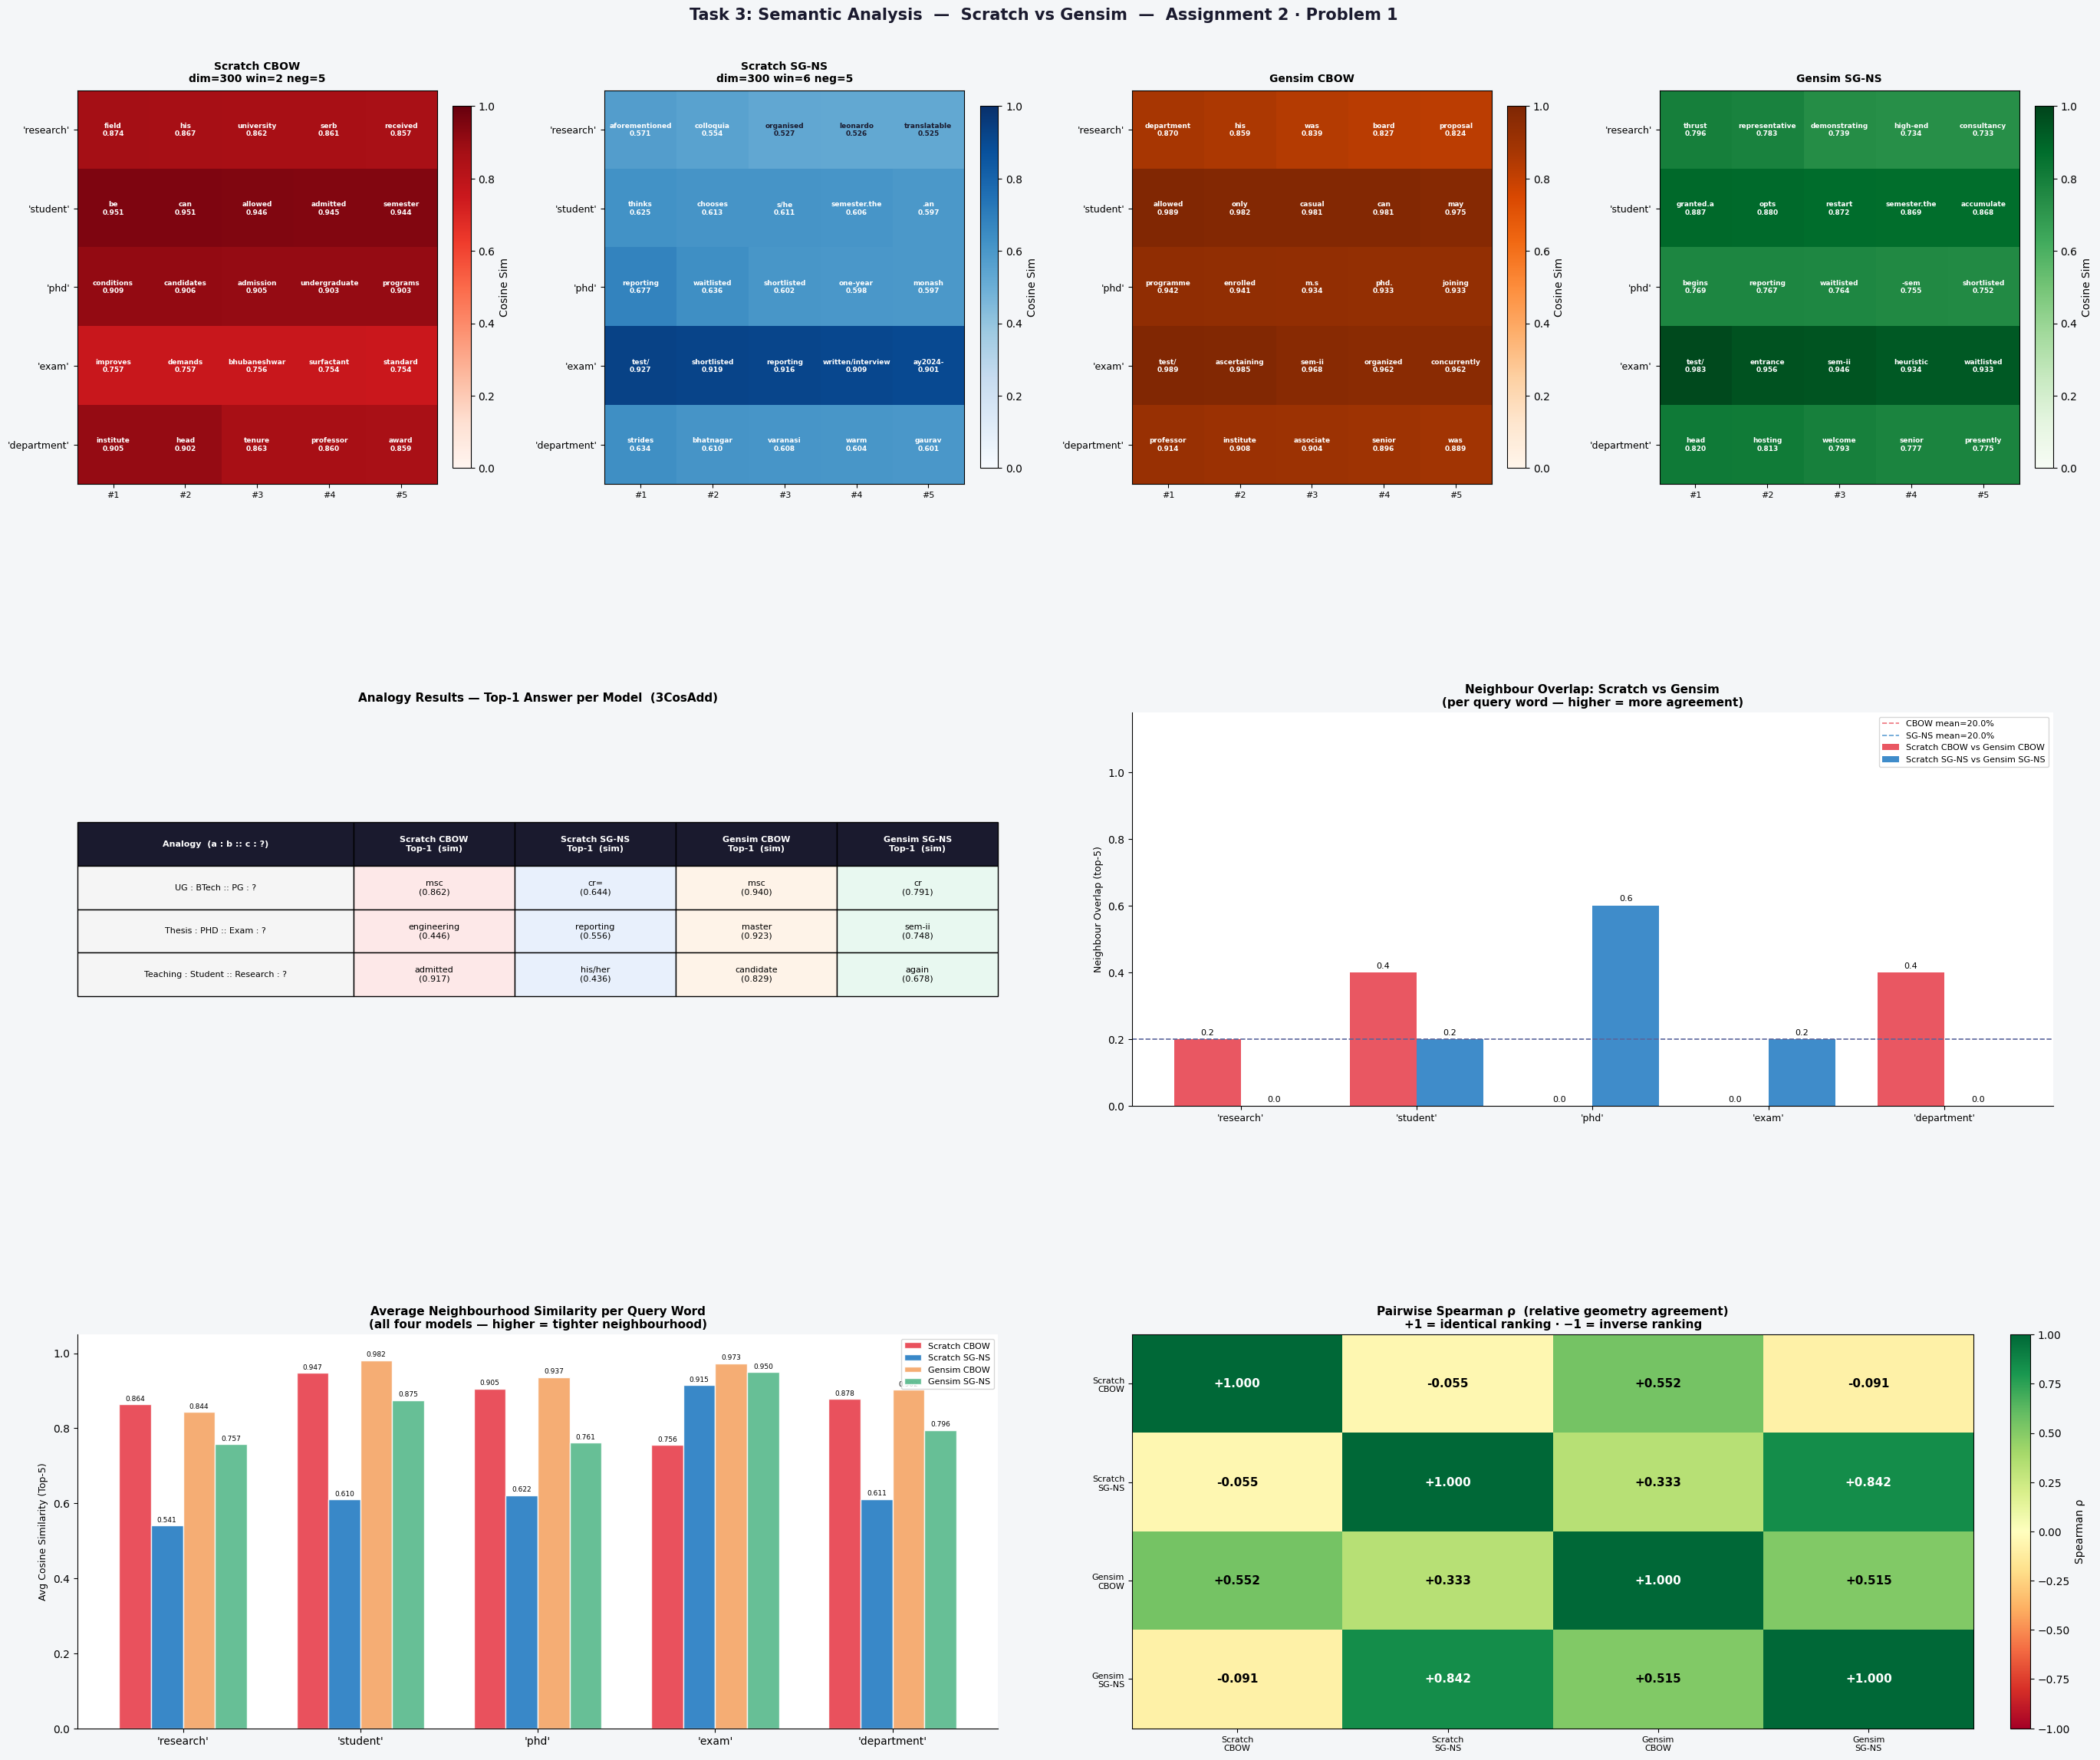

[INFO] Figure saved → word2vec_task3_semantic.png

[DONE] Task 3 complete.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import itertools
from scipy.stats import spearmanr

def pick_best_config(model_type):
    """
    Finds the (embed_dim, win, neg_k) combo with the lowest final-epoch loss.
    Reads the grid values directly from the dict keys so it stays correct
    even if the hyperparameter grid changes between runs.
    """
    all_embed_dims   = sorted(set(k[1] for k in trained_models.keys()))
    all_window_sizes = sorted(set(k[2] for k in trained_models.keys()))
    all_neg_counts   = sorted(set(k[3] for k in trained_models.keys()))

    return min(
        itertools.product(all_embed_dims, all_window_sizes, all_neg_counts),
        key=lambda cfg: trained_models[(model_type, *cfg)].epoch_losses[-1]
    )

best_cbow_hyperparams = pick_best_config('cbow')
best_sg_hyperparams   = pick_best_config('sgns')

best_cbow_model = trained_models[('cbow', *best_cbow_hyperparams)]
best_sg_model   = trained_models[('sgns', *best_sg_hyperparams)]

print(f"[INFO] Best scratch CBOW  : embed_dim={best_cbow_hyperparams[0]}, "
      f"win={best_cbow_hyperparams[1]}, neg_k={best_cbow_hyperparams[2]}  "
      f"loss={best_cbow_model.epoch_losses[-1]:.4f}")
print(f"[INFO] Best scratch SG-NS : embed_dim={best_sg_hyperparams[0]},   "
      f"win={best_sg_hyperparams[1]},   neg_k={best_sg_hyperparams[2]}   "
      f"loss={best_sg_model.epoch_losses[-1]:.4f}")
print(f"[INFO] Gensim CBOW  final loss : {gensim_cbow.get_latest_training_loss():.4f}")
print(f"[INFO] Gensim SG-NS final loss : {gensim_sg.get_latest_training_loss():.4f}\n")

# Collecting all four models into one ordered list used throughout the cell.
# Each entry is (short_label, long_label, model_object, is_gensim).
# is_gensim lets helpers call the right lookup API without branching everywhere.
ALL_MODELS = [
    ('Scratch\nCBOW',  'Scratch CBOW',  best_cbow_model, False),
    ('Scratch\nSG-NS', 'Scratch SG-NS', best_sg_model,   False),
    ('Gensim\nCBOW',   'Gensim CBOW',   gensim_cbow,     True),
    ('Gensim\nSG-NS',  'Gensim SG-NS',  gensim_sg,       True),
]

# Plot colour for each model — kept consistent across every panel
MODEL_COLORS = {
    'Scratch CBOW' : '#e63946',
    'Scratch SG-NS': '#1d78c1',
    'Gensim CBOW'  : '#f4a261',
    'Gensim SG-NS' : '#52b788',
}

# Heatmap colour-map for each model
MODEL_CMAPS = {
    'Scratch CBOW' : 'Reds',
    'Scratch SG-NS': 'Blues',
    'Gensim CBOW'  : 'Oranges',
    'Gensim SG-NS' : 'Greens',
}

# SECTION 1 - COSINE-SIMILARITY HELPERS

def cosine_similarities_scratch(embedding_matrix, query_vec):
    """
    Cosine similarity between query_vec and every row in embedding_matrix.
    Returns a 1-D array of shape (vocab_size,).
    """
    row_norms  = np.linalg.norm(embedding_matrix, axis=1) + 1e-10
    query_norm = np.linalg.norm(query_vec) + 1e-10
    return (embedding_matrix @ query_vec) / (row_norms * query_norm)


def lookup_neighbours_scratch(model_obj, query_word, top_n=5):
    """
    Top-N nearest neighbours for a scratch Word2Vec model.
    Returns OOV placeholder tuples if the word is not in word_to_idx.
    """
    if query_word not in word_to_idx:
        return [('—OOV—', 0.0)] * top_n

    query_idx = word_to_idx[query_word]
    query_vec = model_obj.input_embeddings[query_idx]
    all_sims  = cosine_similarities_scratch(model_obj.input_embeddings, query_vec)
    all_sims[query_idx] = -1.0  # exclude the query word itself

    top_indices = np.argsort(-all_sims)[:top_n]
    return [(idx_to_word[i], float(all_sims[i])) for i in top_indices]


def lookup_neighbours_gensim(gensim_model, query_word, top_n=5):
    """
    Top-N nearest neighbours using Gensim's KeyedVectors.most_similar.
    Returns OOV placeholder tuples if the word is not in the Gensim vocab.
    """
    if query_word not in gensim_model.wv:
        return [('—OOV—', 0.0)] * top_n
    return gensim_model.wv.most_similar(query_word, topn=top_n)


def lookup_neighbours(model_obj, query_word, top_n=5, is_gensim=False):
    """Unified dispatcher so call-sites don't need to branch."""
    if is_gensim:
        return lookup_neighbours_gensim(model_obj, query_word, top_n)
    return lookup_neighbours_scratch(model_obj, query_word, top_n)


def neighbour_overlap(nbrs_a, nbrs_b, top_n=5):
    """
    Fraction of the top-N neighbour lists that share the same words.
    1.0 = identical neighbourhoods; 0.0 = no overlap at all.
    """
    words_a = {w for w, _ in nbrs_a[:top_n]}
    words_b = {w for w, _ in nbrs_b[:top_n]}
    if not words_a or not words_b:
        return 0.0
    return len(words_a & words_b) / top_n

# SECTION 2 — NEAREST-NEIGHBOUR RESULTS

# Covers a range of semantic categories in the IIT Jodhpur corpus: academic roles, processes, qualifications, and administrative units.
QUERY_WORDS    = ['research', 'student', 'phd', 'exam', 'department']
NUM_NEIGHBOURS = 5

print("=" * 80)
print(f"  TOP-{NUM_NEIGHBOURS} NEAREST NEIGHBOURS  (cosine similarity on input embeddings)")
print("=" * 80)

# neighbour_results[(long_label, query_word)] -> list of (word, score) tuples
neighbour_results = {}

for short_lbl, long_lbl, model_obj, is_gensim in ALL_MODELS:

    if is_gensim:
        header = f"{long_lbl}"
    else:
        header = (f"{long_lbl}  "
                  f"(embed_dim={model_obj.embed_dim}, "
                  f"win={model_obj.window_size}, "
                  f"neg_k={model_obj.num_negatives})")
    print(f"\n── {header} ──\n")

    for query_word in QUERY_WORDS:
        nbrs = lookup_neighbours(model_obj, query_word, NUM_NEIGHBOURS, is_gensim)
        neighbour_results[(long_lbl, query_word)] = nbrs

        oov_tag = '' if (query_word in word_to_idx or
                         (is_gensim and query_word in model_obj.wv)) else '  [OOV]'
        print(f"  '{query_word}'{oov_tag}:")
        for rank, (word, score) in enumerate(nbrs, 1):
            print(f"      {rank}. {word:<22}  sim = {score:.4f}")
        print()

print("=" * 80)

# Side-by-side comparison: scratch vs Gensim, per query word 
print("\n" + "=" * 90)
print("  SIDE-BY-SIDE COMPARISON - Scratch vs Gensim  (top-5 neighbours)")
print("=" * 90)

for query_word in QUERY_WORDS:
    print(f"\n  Query: '{query_word}'")
    print(f"  {'Rank':<5}  {'Scratch CBOW':<24}  {'Gensim CBOW':<24}  "
          f"{'Scratch SG-NS':<24}  {'Gensim SG-NS'}")
    print("  " + "─" * 110)

    sc_cbow = neighbour_results[('Scratch CBOW',  query_word)]
    gs_cbow = neighbour_results[('Gensim CBOW',   query_word)]
    sc_sg   = neighbour_results[('Scratch SG-NS', query_word)]
    gs_sg   = neighbour_results[('Gensim SG-NS',  query_word)]

    def fmt(lst, i):
        if i < len(lst):
            w, s = lst[i]
            return f"{w} ({s:.3f})"
        return "—"

    for rank in range(NUM_NEIGHBOURS):
        print(f"  {rank+1:<5}  {fmt(sc_cbow, rank):<24}  {fmt(gs_cbow, rank):<24}  "
              f"  {fmt(sc_sg, rank):<24}  {fmt(gs_sg, rank)}")

print()

# Neighbour-overlap table: scratch vs Gensim
print("=" * 70)
print("  NEIGHBOUR OVERLAP  (fraction of top-5 shared with Gensim reference)")
print("=" * 70)
print(f"  {'Query':<16}  {'Scratch CBOW':>14}  {'Scratch SG-NS':>14}")
print("  " + "─" * 50)

overlap_cbow_vals = []
overlap_sg_vals   = []

for query_word in QUERY_WORDS:
    ov_cbow = neighbour_overlap(
        neighbour_results[('Scratch CBOW',  query_word)],
        neighbour_results[('Gensim CBOW',   query_word)],
        NUM_NEIGHBOURS
    )
    ov_sg = neighbour_overlap(
        neighbour_results[('Scratch SG-NS', query_word)],
        neighbour_results[('Gensim SG-NS',  query_word)],
        NUM_NEIGHBOURS
    )
    overlap_cbow_vals.append(ov_cbow)
    overlap_sg_vals.append(ov_sg)
    print(f"  {query_word:<16}  {ov_cbow:>13.1%}  {ov_sg:>13.1%}")

print("  " + "─" * 50)
print(f"  {'MEAN':<16}  {np.mean(overlap_cbow_vals):>13.1%}  {np.mean(overlap_sg_vals):>13.1%}")
print("=" * 70)


# SECTION 3 - ANALOGY EXPERIMENTS
# Formula: d = argmax cosine( W[b] - W[a] + W[c] )
# Reads as: "a is to b as c is to ?"

def solve_analogy_scratch(model_obj, word_a, word_b, word_c, top_n=5):
    """
    3CosAdd on a scratch Word2Vec model.
    Masks out the three input words and all stopwords so the answer list
    contains genuine semantic candidates rather than trivial echo words.
    """
    missing = [w for w in [word_a, word_b, word_c] if w not in word_to_idx]
    if missing:
        return [(f'OOV:{missing[0]}', 0.0)]

    query_vector = (
          model_obj.input_embeddings[word_to_idx[word_b]]
        - model_obj.input_embeddings[word_to_idx[word_a]]
        + model_obj.input_embeddings[word_to_idx[word_c]]
    )
    scores = cosine_similarities_scratch(model_obj.input_embeddings, query_vector)

    # mask input words and stopwords
    for w in [word_a, word_b, word_c]:
        scores[word_to_idx[w]] = -1.0
    for w in STOP_WORDS:
        if w in word_to_idx:
            scores[word_to_idx[w]] = -1.0

    top_indices = np.argsort(-scores)[:top_n]
    return [(idx_to_word[i], float(scores[i])) for i in top_indices]


def solve_analogy_gensim(gensim_model, word_a, word_b, word_c, top_n=5):
    """
    3CosAdd via Gensim's most_similar(positive=[b, c], negative=[a]).
    Gensim internally masks the three input words from the result list, so
    we only need to check for OOV.
    """
    missing = [w for w in [word_a, word_b, word_c] if w not in gensim_model.wv]
    if missing:
        return [(f'OOV:{missing[0]}', 0.0)]

    # Gensim's most_similar with positive/negative implements 3CosAdd:
    #   query = W[word_b] + W[word_c] - W[word_a]
    return gensim_model.wv.most_similar(
        positive=[word_b, word_c],
        negative=[word_a],
        topn=top_n
    )


def solve_analogy(model_obj, word_a, word_b, word_c, top_n=5, is_gensim=False):
    """Unified dispatcher for analogy solving."""
    if is_gensim:
        return solve_analogy_gensim(model_obj, word_a, word_b, word_c, top_n)
    return solve_analogy_scratch(model_obj, word_a, word_b, word_c, top_n)


# Each triple is (word_a, word_b, word_c, human-readable description).
# Chosen to probe different semantic relationships in the IIT Jodhpur corpus.
ANALOGY_TRIPLES = [
    # degree-level: undergraduate→btech, so postgraduate→?
    ('ug',       'btech',   'pg',       'UG : BTech :: PG : ?'),
    # artefact-to-programme: thesis belongs to phd, exam belongs to?
    ('thesis',   'phd',     'exam',     'Thesis : PHD :: Exam : ?'),
    # role: teaching involves students, research involves?
    ('teaching', 'student', 'research', 'Teaching : Student :: Research : ?'),
]

print("\n" + "=" * 80)
print("  ANALOGY EXPERIMENTS  (a : b :: c : ?)  —  all four models")
print("=" * 80)

# analogy_results[(long_label, analogy_idx)] -> list of (word, score)
analogy_results = {}

for short_lbl, long_lbl, model_obj, is_gensim in ALL_MODELS:
    print(f"\n── {long_lbl} ──\n")

    for analogy_idx, (word_a, word_b, word_c, description) in enumerate(ANALOGY_TRIPLES):
        top_answers = solve_analogy(model_obj, word_a, word_b, word_c,
                                    top_n=5, is_gensim=is_gensim)
        analogy_results[(long_lbl, analogy_idx)] = top_answers

        # flag any OOV inputs so the reader knows the result can't be trusted
        vocab_ref = model_obj.wv if is_gensim else word_to_idx
        oov_words = [w for w in [word_a, word_b, word_c] if w not in vocab_ref]
        oov_note  = f"  [OOV: {', '.join(oov_words)}]" if oov_words else ""

        print(f"  {description}{oov_note}")
        for rank, (answer_word, sim_score) in enumerate(top_answers, 1):
            print(f"      {rank}. {answer_word:<22}  sim = {sim_score:.4f}")
        print()

print("=" * 80)

# Cross-model analogy comparison table
print("\n" + "=" * 100)
print("  ANALOGY TOP-1 CROSS-MODEL COMPARISON")
print("=" * 100)
col_w = 22
header_parts = [f"{'Analogy':<38}"]
for _, long_lbl, _, _ in ALL_MODELS:
    header_parts.append(f"{long_lbl[:col_w]:<{col_w}}")
print("  " + "  ".join(header_parts))
print("  " + "─" * 96)

for analogy_idx, (_, _, _, description) in enumerate(ANALOGY_TRIPLES):
    row_parts = [f"{description:<38}"]
    for _, long_lbl, _, _ in ALL_MODELS:
        answers = analogy_results[(long_lbl, analogy_idx)]
        top_word, top_score = answers[0] if answers else ('—', 0.0)
        cell = f"{top_word} ({top_score:.3f})"
        row_parts.append(f"{cell:<{col_w}}")
    print("  " + "  ".join(row_parts))

print("=" * 100)

# Analogy agreement matrix
# For each analogy, check whether each pair of models agrees on the top-1 answer.
print("\n" + "=" * 70)
print("  ANALOGY TOP-1 AGREEMENT  (✓ = same top answer, ✗ = different)")
print("=" * 70)
label_pairs = [(a[1], b[1]) for i, a in enumerate(ALL_MODELS)
                             for b in ALL_MODELS[i+1:]]
for analogy_idx, (_, _, _, description) in enumerate(ANALOGY_TRIPLES):
    print(f"\n  '{description}'")
    for lbl_a, lbl_b in label_pairs:
        ans_a = analogy_results[(lbl_a, analogy_idx)][0][0]
        ans_b = analogy_results[(lbl_b, analogy_idx)][0][0]
        symbol = '✓' if ans_a == ans_b else '✗'
        print(f"    {symbol}  {lbl_a:<18} vs {lbl_b:<18}  "
              f"({ans_a!r:>16}  vs  {ans_b!r})")

print()

# SECTION 4 - PAIRWISE SIMILARITY CORRELATION  (Spearman ρ)
# Computes the similarity matrix over the query words for each model and then measures rank-correlation between every pair of models.
# A high ρ means two models learned the same *relative* geometry.

def build_sim_matrix_scratch(model_obj, words):
    """VxV cosine-similarity matrix for the given word list (scratch model)."""
    valid = [w for w in words if w in word_to_idx]
    if len(valid) < 2:
        return None, []
    vecs = np.array([model_obj.input_embeddings[word_to_idx[w]] for w in valid])
    vecs = vecs / (np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-10)
    return vecs @ vecs.T, valid


def build_sim_matrix_gensim(gensim_model, words):
    """VxV cosine-similarity matrix for the given word list (Gensim model)."""
    valid = [w for w in words if w in gensim_model.wv]
    if len(valid) < 2:
        return None, []
    vecs = np.array([gensim_model.wv[w] for w in valid])
    vecs = vecs / (np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-10)
    return vecs @ vecs.T, valid


def upper_tri(matrix):
    """Strict upper triangle as a 1-D array (used for Spearman input)."""
    n   = matrix.shape[0]
    idx = np.triu_indices(n, k=1)
    return matrix[idx]


def get_sim_matrix(model_obj, words, is_gensim):
    if is_gensim:
        return build_sim_matrix_gensim(model_obj, words)
    return build_sim_matrix_scratch(model_obj, words)


# Build all four similarity matrices over the query words
sim_matrices = {}
for short_lbl, long_lbl, model_obj, is_gensim in ALL_MODELS:
    mat, valid_words = get_sim_matrix(model_obj, QUERY_WORDS, is_gensim)
    sim_matrices[long_lbl] = (mat, valid_words)

# Compute Spearman ρ for every pair of models
print("=" * 65)
print("  PAIRWISE SPEARMAN ρ  (relative geometry agreement)")
print("  Computed over the query-word similarity matrices")
print("=" * 65)

model_labels_flat = [long_lbl for _, long_lbl, _, _ in ALL_MODELS]
spearman_matrix   = np.full((4, 4), np.nan)

for i, lbl_a in enumerate(model_labels_flat):
    for j, lbl_b in enumerate(model_labels_flat):
        if i == j:
            spearman_matrix[i, j] = 1.0
            continue
        mat_a, va = sim_matrices[lbl_a]
        mat_b, vb = sim_matrices[lbl_b]
        if mat_a is None or mat_b is None:
            continue
        # only compare over words present in both models
        common = [w for w in va if w in vb]
        if len(common) < 2:
            continue
        idx_a = [va.index(w) for w in common]
        idx_b = [vb.index(w) for w in common]
        sub_a = mat_a[np.ix_(idx_a, idx_a)]
        sub_b = mat_b[np.ix_(idx_b, idx_b)]
        rho, pval = spearmanr(upper_tri(sub_a), upper_tri(sub_b))
        spearman_matrix[i, j] = rho

short_labels_flat = [short_lbl.replace('\n', ' ') for short_lbl, *_ in ALL_MODELS]
header = f"  {'':22}" + "".join(f"{lbl:>16}" for lbl in short_labels_flat)
print(header)
print("  " + "─" * (22 + 16 * 4))
for i, lbl in enumerate(short_labels_flat):
    row = f"  {lbl:<22}"
    for j in range(4):
        val = spearman_matrix[i, j]
        row += f"  {val:>+.4f}    " if not np.isnan(val) else f"  {'—':>8}    "
    print(row)
print("=" * 65)

# SECTION 5 — VISUALISATION
#
# Figure layout (4 rows × 4 cols):
#   Row 0: Neighbour heatmaps - one per model (Scratch CBOW, Scratch SG-NS,
#           Gensim CBOW, Gensim SG-NS)
#   Row 1 cols 0-1: Analogy comparison table (full width of left half)
#   Row 1 cols 2-3: Neighbour-overlap bar chart (scratch vs Gensim)
#   Row 2 cols 0-1: Average neighbourhood similarity - all four models
#   Row 2 cols 2-3: Spearman ρ heat-matrix

fig = plt.figure(figsize=(28, 24))
fig.patch.set_facecolor('#f4f6f8')

gs = gridspec.GridSpec(
    3, 4, figure=fig,
    hspace=0.58, wspace=0.34,
    top=0.93, bottom=0.04,
    left=0.05, right=0.97
)

# ── Row 0: four neighbour heatmaps ────────────────────────────────────────────
for col_idx, (short_lbl, long_lbl, model_obj, is_gensim) in enumerate(ALL_MODELS):

    ax = fig.add_subplot(gs[0, col_idx])
    ax.set_facecolor('#ffffff')
    cmap = MODEL_CMAPS[long_lbl]

    sim_grid       = np.zeros((len(QUERY_WORDS), NUM_NEIGHBOURS))
    cell_labels    = []

    for row_idx, query_word in enumerate(QUERY_WORDS):
        nbrs = neighbour_results[(long_lbl, query_word)]
        row_words = []
        for col, (word, score) in enumerate(nbrs):
            sim_grid[row_idx, col] = max(score, 0.0)   # clip negatives for display
            row_words.append(word)
        cell_labels.append(row_words)

    im = ax.imshow(sim_grid, cmap=cmap, aspect='auto', vmin=0, vmax=1)

    ax.set_yticks(range(len(QUERY_WORDS)))
    ax.set_yticklabels([f"'{w}'" for w in QUERY_WORDS], fontsize=9)
    ax.set_xticks(range(NUM_NEIGHBOURS))
    ax.set_xticklabels([f'#{i+1}' for i in range(NUM_NEIGHBOURS)], fontsize=8)

    if is_gensim:
        subtitle = long_lbl
    else:
        subtitle = (f"{long_lbl}\n"
                    f"dim={model_obj.embed_dim} "
                    f"win={model_obj.window_size} "
                    f"neg={model_obj.num_negatives}")
    ax.set_title(subtitle, fontsize=10, fontweight='bold', pad=8)

    for ri in range(len(QUERY_WORDS)):
        for ci in range(NUM_NEIGHBOURS):
            word_lbl = cell_labels[ri][ci]
            score    = sim_grid[ri, ci]
            txt_col  = 'white' if score > 0.55 else '#1a1a2e'
            ax.text(ci, ri, f'{word_lbl}\n{score:.3f}',
                    ha='center', va='center',
                    fontsize=6.5, color=txt_col, fontweight='bold')

    plt.colorbar(im, ax=ax, label='Cosine Sim', fraction=0.046, pad=0.04)

# Row 1 left (cols 0-1): Analogy comparison table
ax_tbl = fig.add_subplot(gs[1, :2])
ax_tbl.axis('off')

col_headers = ['Analogy  (a : b :: c : ?)'] + [
    f"{long_lbl}\nTop-1  (sim)"
    for _, long_lbl, _, _ in ALL_MODELS
]

tbl_rows = []
for analogy_idx, (_, _, _, description) in enumerate(ANALOGY_TRIPLES):
    row = [description]
    for _, long_lbl, _, _ in ALL_MODELS:
        answers = analogy_results[(long_lbl, analogy_idx)]
        top_word, top_score = answers[0] if answers else ('—', 0.0)
        row.append(f"{top_word}\n({top_score:.3f})")
    tbl_rows.append(row)

tbl = ax_tbl.table(
    cellText  = tbl_rows,
    colLabels = col_headers,
    cellLoc   = 'center',
    loc       = 'center',
    colWidths = [0.30, 0.175, 0.175, 0.175, 0.175],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 3.4)

# header styling
for ci in range(len(col_headers)):
    tbl[(0, ci)].set_facecolor('#1a1a2e')
    tbl[(0, ci)].set_text_props(color='white', fontweight='bold')

# colour-code data columns by model
col_bg = {
    1: '#fde8e8',   # Scratch CBOW
    2: '#e8f0fc',   # Scratch SG-NS
    3: '#fef3e8',   # Gensim CBOW
    4: '#e8f8f0',   # Gensim SG-NS
}
for ri in range(1, len(tbl_rows) + 1):
    tbl[(ri, 0)].set_facecolor('#f5f5f5')
    for ci in range(1, 5):
        tbl[(ri, ci)].set_facecolor(col_bg[ci])

ax_tbl.set_title('Analogy Results — Top-1 Answer per Model  (3CosAdd)',
                 fontsize=11, fontweight='bold', pad=10)

# Row 1 right (cols 2-3): Neighbour-overlap bar chart
ax_ov = fig.add_subplot(gs[1, 2:])
ax_ov.set_facecolor('#ffffff')

x_ov   = np.arange(len(QUERY_WORDS))
bw_ov  = 0.38

bars_cbow = ax_ov.bar(x_ov - bw_ov / 2, overlap_cbow_vals,
                      bw_ov, color=MODEL_COLORS['Scratch CBOW'],
                      alpha=0.85, label='Scratch CBOW vs Gensim CBOW')
bars_sg   = ax_ov.bar(x_ov + bw_ov / 2, overlap_sg_vals,
                      bw_ov, color=MODEL_COLORS['Scratch SG-NS'],
                      alpha=0.85, label='Scratch SG-NS vs Gensim SG-NS')

ax_ov.bar_label(bars_cbow, fmt='%.1f', padding=3, fontsize=8)
ax_ov.bar_label(bars_sg,   fmt='%.1f', padding=3, fontsize=8)

# mean reference lines
ax_ov.axhline(np.mean(overlap_cbow_vals), color=MODEL_COLORS['Scratch CBOW'],
              linestyle='--', linewidth=1.2, alpha=0.7,
              label=f"CBOW mean={np.mean(overlap_cbow_vals):.1%}")
ax_ov.axhline(np.mean(overlap_sg_vals), color=MODEL_COLORS['Scratch SG-NS'],
              linestyle='--', linewidth=1.2, alpha=0.7,
              label=f"SG-NS mean={np.mean(overlap_sg_vals):.1%}")

ax_ov.set_xticks(x_ov)
ax_ov.set_xticklabels([f"'{w}'" for w in QUERY_WORDS], fontsize=9)
ax_ov.set_ylim(0, 1.18)
ax_ov.set_ylabel('Neighbour Overlap (top-5)', fontsize=9)
ax_ov.set_title('Neighbour Overlap: Scratch vs Gensim\n'
                '(per query word — higher = more agreement)',
                fontsize=11, fontweight='bold')
ax_ov.legend(fontsize=8, loc='upper right')
ax_ov.spines[['top', 'right']].set_visible(False)

# Row 2 left (cols 0-1): Average neighbourhood similarity - all four models
ax_avg = fig.add_subplot(gs[2, :2])
ax_avg.set_facecolor('#ffffff')

n_models  = len(ALL_MODELS)
bw_avg    = 0.18
x_avg     = np.arange(len(QUERY_WORDS))

for m_idx, (short_lbl, long_lbl, model_obj, is_gensim) in enumerate(ALL_MODELS):
    avg_sims = [
        np.mean([score for _, score in neighbour_results[(long_lbl, q)]])
        for q in QUERY_WORDS
    ]
    offset = (m_idx - (n_models - 1) / 2) * bw_avg
    bars = ax_avg.bar(x_avg + offset, avg_sims, bw_avg,
                      color=MODEL_COLORS[long_lbl], alpha=0.88,
                      label=long_lbl, edgecolor='white')
    ax_avg.bar_label(bars, fmt='%.3f', padding=2, fontsize=6.5)

ax_avg.set_xticks(x_avg)
ax_avg.set_xticklabels([f"'{w}'" for w in QUERY_WORDS], fontsize=10)
ax_avg.set_ylabel('Avg Cosine Similarity (Top-5)', fontsize=9)
ax_avg.set_title('Average Neighbourhood Similarity per Query Word\n'
                 '(all four models — higher = tighter neighbourhood)',
                 fontsize=11, fontweight='bold')

ax_avg.legend(fontsize=8, loc='upper right')
ax_avg.spines[['top', 'right']].set_visible(False)
max_val = max(
    np.mean([score for _, score in neighbour_results[(long_lbl, q)]])
    for _, long_lbl, _, _ in ALL_MODELS
    for q in QUERY_WORDS
)
ax_avg.set_ylim(0, min(1.05, max_val + 0.18))

# Row 2 right (cols 2-3): Spearman ρ heat-matrix
ax_rho = fig.add_subplot(gs[2, 2:])
ax_rho.set_facecolor('#ffffff')

rho_im = ax_rho.imshow(spearman_matrix, cmap='RdYlGn', vmin=-1, vmax=1,
                        aspect='auto')
ax_rho.set_xticks(range(4))
ax_rho.set_yticks(range(4))
tick_lbl = [lbl.replace('\n', '\n') for lbl, *_ in ALL_MODELS]
ax_rho.set_xticklabels(tick_lbl, fontsize=8)
ax_rho.set_yticklabels(tick_lbl, fontsize=8)

for i in range(4):
    for j in range(4):
        val = spearman_matrix[i, j]
        if not np.isnan(val):
            txt_col = 'black' if abs(val) < 0.6 else 'white'
            ax_rho.text(j, i, f'{val:+.3f}',
                        ha='center', va='center',
                        fontsize=11, color=txt_col, fontweight='bold')

plt.colorbar(rho_im, ax=ax_rho, label='Spearman ρ', fraction=0.046, pad=0.04)
ax_rho.set_title('Pairwise Spearman ρ  (relative geometry agreement)\n'
                 '+1 = identical ranking · −1 = inverse ranking',
                 fontsize=11, fontweight='bold')

fig.suptitle(
    'Task 3: Semantic Analysis  —  Scratch vs Gensim  —  Assignment 2 · Problem 1',
    fontsize=15, fontweight='bold', y=0.975, color='#1a1a2e'
)

plt.savefig('word2vec_task3_semantic.png', dpi=130,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("[INFO] Figure saved → word2vec_task3_semantic.png")
print("\n[DONE] Task 3 complete.")

[INFO] Best CBOW  : embed_dim=300, win=2, neg_k=5, loss=2.5724
[INFO] Best SG-NS : embed_dim=300,   win=6,   neg_k=5,   loss=1.2359

[INFO] Clusters and vocabulary coverage:
  Academic Programmes       10/10 words in vocab : ['btech', 'mtech', 'phd', 'msc', 'mba', 'ug', 'pg', 'degree', 'programme', 'curriculum']
  Research                  9/9 words in vocab : ['research', 'thesis', 'publication', 'laboratory', 'project', 'innovation', 'grant', 'conference', 'paper']
  People                    8/8 words in vocab : ['student', 'faculty', 'professor', 'director', 'registrar', 'advisor', 'scholar', 'researcher']
  Academics                 10/10 words in vocab : ['exam', 'semester', 'course', 'lecture', 'syllabus', 'assignment', 'grade', 'credit', 'attendance', 'marks']
  Infrastructure            9/10 words in vocab : ['campus', 'library', 'laboratory', 'building', 'facility', 'infrastructure', 'department', 'centre', 'hall']
  Administration            8/8 words in vocab : ['senate', '

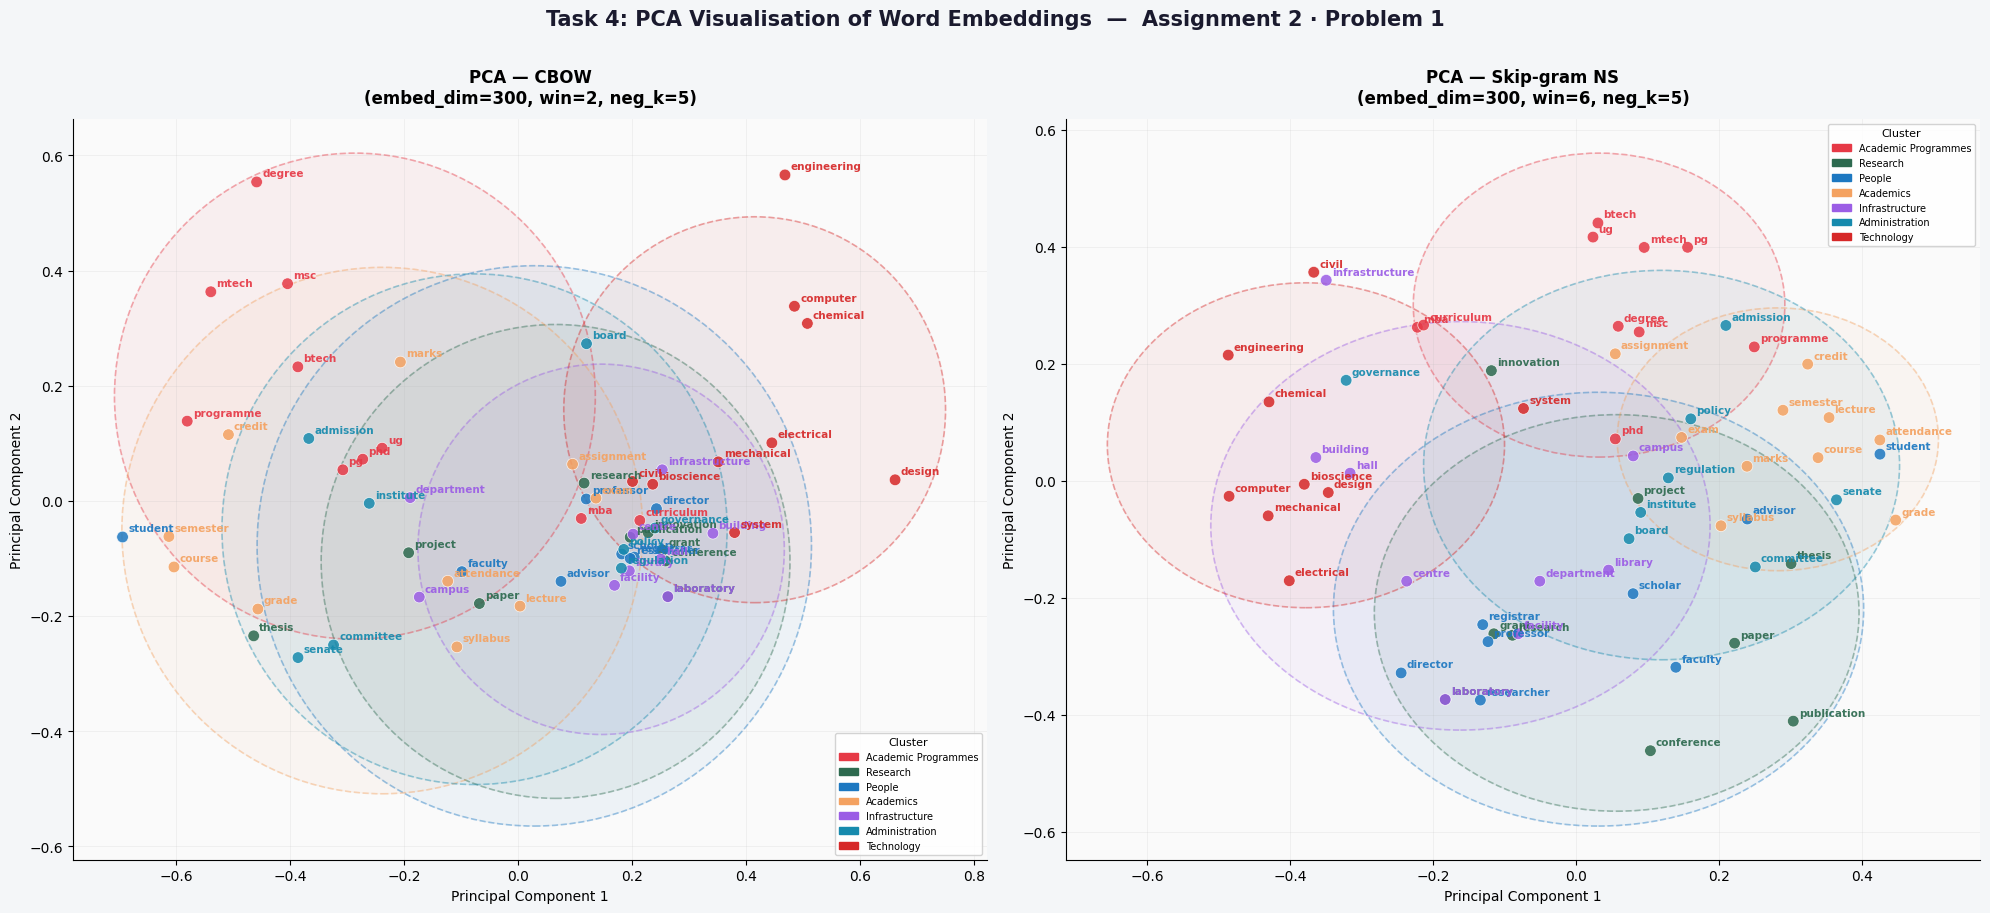

[INFO] Figure saved → word2vec_task4_visualization.png

[DONE] Task 4 complete.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

# LOADING BEST MODELS FROM TASK 2

best_cbow_hyperparams = pick_best_config('cbow')
best_sg_hyperparams   = pick_best_config('sgns')

best_cbow_model = trained_models[('cbow', *best_cbow_hyperparams)]
best_sg_model   = trained_models[('sgns', *best_sg_hyperparams)]

print(f"[INFO] Best CBOW  : embed_dim={best_cbow_hyperparams[0]}, "
      f"win={best_cbow_hyperparams[1]}, neg_k={best_cbow_hyperparams[2]}, "
      f"loss={best_cbow_model.epoch_losses[-1]:.4f}")
print(f"[INFO] Best SG-NS : embed_dim={best_sg_hyperparams[0]},   "
      f"win={best_sg_hyperparams[1]},   neg_k={best_sg_hyperparams[2]},   "
      f"loss={best_sg_model.epoch_losses[-1]:.4f}\n")

# DEFINE SEMANTIC WORD CLUSTERS
# seven thematic groups relevant to IIT Jodhpur - if these separate
# cleanly in PCA space it means the embeddings have learned realsemantic structure rather than just statistical co-occurrence noise

RAW_CLUSTER_DEFINITIONS = {
    'Academic Programmes': [
        'btech', 'mtech', 'phd', 'msc', 'mba',
        'ug', 'pg', 'degree', 'programme', 'curriculum'
    ],
    'Research': [
        'research', 'thesis', 'publication', 'laboratory',
        'project', 'innovation', 'grant', 'conference', 'paper'
    ],
    'People': [
        'student', 'faculty', 'professor', 'director',
        'registrar', 'advisor', 'scholar', 'researcher'
    ],
    'Academics': [
        'exam', 'semester', 'course', 'lecture', 'syllabus',
        'assignment', 'grade', 'credit', 'attendance', 'marks'
    ],
    'Infrastructure': [
        'campus', 'hostel', 'library', 'laboratory', 'building',
        'facility', 'infrastructure', 'department', 'centre', 'hall'
    ],
    'Administration': [
        'senate', 'committee', 'regulation', 'policy',
        'admission', 'institute', 'board', 'governance'
    ],
    'Technology': [
        'engineering', 'computer', 'electrical', 'mechanical',
        'chemical', 'civil', 'bioscience', 'design', 'system'
    ],
}

# one distinct colour per cluster - same red/blue anchors used for CBOW/SG-NS throughout Tasks 2 and 3, extended with more distinct hues
CLUSTER_COLOR_PALETTE = [
    '#e63946',  # red          - Academic Programmes
    '#2d6a4f',  # dark green   - Research
    '#1d78c1',  # blue         - People
    '#f4a261',  # orange       - Academics
    '#9b5de5',  # purple       - Infrastructure
    '#168aad',  # teal         - Administration
    '#d62828',  # crimson      - Technology
]

# silently drop any word that didn't make it into the vocabulary - no point plotting a word we have no embedding for
vocab_filtered_clusters = {}
for cluster_name, word_list in RAW_CLUSTER_DEFINITIONS.items():
    in_vocab_words = [w for w in word_list if w in word_to_idx]
    if in_vocab_words:
        vocab_filtered_clusters[cluster_name] = in_vocab_words

print("[INFO] Clusters and vocabulary coverage:")
total_plottable_words = 0
for cluster_name, word_list in vocab_filtered_clusters.items():
    raw_count   = len(RAW_CLUSTER_DEFINITIONS[cluster_name])
    valid_count = len(word_list)
    total_plottable_words += valid_count
    print(f"  {cluster_name:<25} {valid_count}/{raw_count} words in vocab : {word_list}")
print(f"\n[INFO] Total words for visualisation: {total_plottable_words}\n")

# EMBEDDING EXTRACTION + PCA PROJECTION

def gather_cluster_embeddings(model, cluster_dict):
    """
    Pulls the embedding vector for every word in every cluster and packages up the colour/label metadata needed for plotting.
    Vectors are L2-normalised before returning - puts everything on the unit hypersphere so cosine distance equals Euclidean distance and
    PCA spread is easier to interpret.
    """
    embedding_list = []
    word_labels    = []
    point_colors   = []
    cluster_tags   = []

    for cluster_idx, (cluster_name, word_list) in enumerate(cluster_dict.items()):
        # cycle through the palette if there are ever more clusters than colours
        assigned_color = CLUSTER_COLOR_PALETTE[cluster_idx % len(CLUSTER_COLOR_PALETTE)]
        for word in word_list:
            if word in word_to_idx:
                embedding_list.append(model.input_embeddings[word_to_idx[word]])
                word_labels.append(word)
                point_colors.append(assigned_color)
                cluster_tags.append(cluster_name)

    embedding_matrix = normalize(np.array(embedding_list), norm='l2')
    return embedding_matrix, word_labels, point_colors, cluster_tags


def project_to_2d(embedding_matrix):
    """
    Reduces (N, D) embeddings to (N, 2) with PCA.
    Using PCA over t-SNE here because it's deterministic, preserves global inter-cluster distances rather than just local neighbourhoods, and
    needs no hyperparameter tuning. random_state is fixed for reproducibility.
    """
    pca = PCA(n_components=2, random_state=42)
    return pca.fit_transform(embedding_matrix)

# COMPUTING PCA PROJECTIONS FOR BOTH MODELS

print("[INFO] Extracting embeddings …")
cbow_emb_matrix, cbow_word_labels, cbow_point_colors, cbow_cluster_tags = \
    gather_cluster_embeddings(best_cbow_model, vocab_filtered_clusters)

sg_emb_matrix, sg_word_labels, sg_point_colors, sg_cluster_tags = \
    gather_cluster_embeddings(best_sg_model, vocab_filtered_clusters)

print(f"[INFO] Running PCA for CBOW  "
      f"({cbow_emb_matrix.shape[0]} words × {cbow_emb_matrix.shape[1]} dims) …")
cbow_2d = project_to_2d(cbow_emb_matrix)

print(f"[INFO] Running PCA for SG-NS "
      f"({sg_emb_matrix.shape[0]} words × {sg_emb_matrix.shape[1]} dims) …")
sg_2d = project_to_2d(sg_emb_matrix)

print("[INFO] Projections done.\n")

# PLOTTING HELPER

def plot_embedding_scatter(ax, coords_2d, word_labels, point_colors,
                           cluster_tags, plot_title, include_legend=True):
    """
    Draws a 2D scatter of PCA-projected embeddings. Each point is coloured by its semantic cluster, labelled with its word, and surrounded by a
    soft circle showing the cluster's spread - makes it easy to see at a glance whether semantically related words ended up close together.
    """
    # scatter the word points
    ax.scatter(coords_2d[:, 0], coords_2d[:, 1],
               c=point_colors, s=70, alpha=0.85,
               edgecolors='white', linewidths=0.5, zorder=3)

    # label each point - small offset so the text doesn't sit on the dot
    for word_idx, (word, x, y) in enumerate(
            zip(word_labels, coords_2d[:, 0], coords_2d[:, 1])):
        ax.annotate(
            word,
            xy=(x, y),
            xytext=(4, 4),
            textcoords='offset points',
            fontsize=7.5,
            color=point_colors[word_idx],
            fontweight='bold',
            alpha=0.92,
        )

    # draw a soft circle around each cluster's centroid so the groupings are obvious even when points from different clusters overlap
    cluster_to_color = {
        name: CLUSTER_COLOR_PALETTE[idx % len(CLUSTER_COLOR_PALETTE)]
        for idx, name in enumerate(vocab_filtered_clusters.keys())
    }

    # dict.fromkeys deduplicates cluster_tags while preserving insertion order
    for cluster_name in dict.fromkeys(cluster_tags):
        member_indices = [i for i, tag in enumerate(cluster_tags)
                          if tag == cluster_name]
        if len(member_indices) < 2:
            continue   # a single point doesn't need a circle

        cluster_points = coords_2d[member_indices]
        cx = cluster_points[:, 0].mean()
        cy = cluster_points[:, 1].mean()

        # radius scales with the standard deviation of the cluster - tighter groups get smaller circles, spread-out ones get bigger
        spread = max(np.std(cluster_points[:, 0]),
                     np.std(cluster_points[:, 1]))
        radius       = spread * 1.5 + 0.05
        cluster_color = cluster_to_color.get(cluster_name, 'grey')

        # faint fill to softly highlight the region
        ax.add_patch(plt.Circle(
            (cx, cy), radius,
            color=cluster_color, fill=True, alpha=0.06, zorder=1
        ))
        # dashed border to mark the cluster boundary clearly
        ax.add_patch(plt.Circle(
            (cx, cy), radius,
            color=cluster_color, fill=False,
            alpha=0.40, linewidth=1.2, linestyle='--', zorder=2
        ))

    if include_legend:
        legend_patches = [
            mpatches.Patch(
                color=CLUSTER_COLOR_PALETTE[idx % len(CLUSTER_COLOR_PALETTE)],
                label=cluster_name
            )
            for idx, cluster_name in enumerate(vocab_filtered_clusters.keys())
        ]
        ax.legend(handles=legend_patches, fontsize=7, loc='best',
                  framealpha=0.85, title='Cluster', title_fontsize=8)

    # same spine style used throughout Tasks 2 and 3
    ax.set_title(plot_title, fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('Principal Component 1', fontsize=10)
    ax.set_ylabel('Principal Component 2', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_facecolor('#fafafa')
    ax.grid(True, alpha=0.2, linewidth=0.5)

# FIGURE  (1 row × 2 cols — CBOW left, SG-NS right)

fig, (ax_cbow, ax_sg) = plt.subplots(1, 2, figsize=(20, 9))
fig.patch.set_facecolor('#f4f6f8')

# build title strings up here so the plotting calls stay readable
cbow_plot_title = (
    f'PCA — CBOW\n'
    f'(embed_dim={best_cbow_model.embed_dim}, '
    f'win={best_cbow_model.window_size}, '
    f'neg_k={best_cbow_model.num_negatives})'
)
sg_plot_title = (
    f'PCA — Skip-gram NS\n'
    f'(embed_dim={best_sg_model.embed_dim}, '
    f'win={best_sg_model.window_size}, '
    f'neg_k={best_sg_model.num_negatives})'
)

# same helper for both panels so the styling is guaranteed consistent
plot_embedding_scatter(ax_cbow,
                       cbow_2d, cbow_word_labels,
                       cbow_point_colors, cbow_cluster_tags,
                       cbow_plot_title, include_legend=True)

plot_embedding_scatter(ax_sg,
                       sg_2d, sg_word_labels,
                       sg_point_colors, sg_cluster_tags,
                       sg_plot_title, include_legend=True)

fig.suptitle(
    'Task 4: PCA Visualisation of Word Embeddings  —  Assignment 2 · Problem 1',
    fontsize=15, fontweight='bold', y=1.01, color='#1a1a2e'
)

plt.tight_layout()
plt.savefig('word2vec_task4_visualization.png', dpi=130,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("[INFO] Figure saved → word2vec_task4_visualization.png")
print("\n[DONE] Task 4 complete.")